<a href="https://colab.research.google.com/github/NicholasMaestrello/01_nicholas_git/blob/master/Notebook_Estudo_de_Caso2_HappinessReportAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **MBA em IA e BIGDATA**
## **CURSO 2 - CD, AM e DM**
## **Profa. Roseli Aparecida Francelin Romero**


## **OBJETIVO:** Análise da felicidade ao redor do Mundo


[Base de dados no Kaggle](https://www.kaggle.com/datasets/jainaru/world-happiness-report-2024-yearly-updated?select=World-happiness-report-updated_2024.csv)

Obs: É necessário fazer upload de ambos os arquivos 'World-happiness-report-updated_2024.csv' e 'World-happiness-report-2024.csv'

## Descrição dos atributos da base


* Country name: Name of the country.
* Regional indicator: Region to which the country belongs.
* Ladder score: The happiness score for each country, based on responses to the Cantril Ladder question that asks respondents to think of a ladder, with the best possible life for them being a 10, and the worst possible life being a 0.
* Log GDP per capita: The natural logarithm of the country's GDP per capita, adjusted for purchasing power parity (PPP) to account for differences in the cost of living between countries.
* Social support: The national average of binary responses(either 0 or 1 representing No/Yes) to the question about having relatives or friends to count on in times of trouble.
* Healthy life expectancy: The average number of years a newborn infant would live in good health, based on mortality rates and life expectancy at different ages.
* Freedom to make life choices: The national average of responses to the question about satisfaction with freedom to choose what to do with one's life.
* Generosity: The residual of regressing the national average of responses to the question about donating money to charity on GDP per capita.
* Perceptions of corruption: The national average of survey responses to questions about the perceived extent of corruption in the government and businesses.
* Positive affect: The national average of responses to questions about positive emotions experienced yesterday.
* Negative affect: The national average of responses to questions about negative emotions experienced yesterday.
* Regional indicator: The region that the country is part of




# Pré-processamento

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_predict

# Interpretabilidade
import shap



In [ ]:
#LENDO DADOS DO PRIMEIRO ARQUIVO
df1 = pd.read_csv("/content/World-happiness-report-updated_2024.csv", encoding = 'latin-1')
df1.head(20)

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.350,0.451,50.500,0.718,0.164,0.882,0.414,0.258
1,Afghanistan,2009,4.402,7.509,0.552,50.800,0.679,0.187,0.850,0.481,0.237
2,Afghanistan,2010,4.758,7.614,0.539,51.100,0.600,0.118,0.707,0.517,0.275
3,Afghanistan,2011,3.832,7.581,0.521,51.400,0.496,0.160,0.731,0.480,0.267
4,Afghanistan,2012,3.783,7.661,0.521,51.700,0.531,0.234,0.776,0.614,0.268
5,Afghanistan,2013,3.572,7.680,0.484,52.000,0.578,0.059,0.823,0.547,0.273
6,Afghanistan,2014,3.131,7.671,0.526,52.300,0.509,0.102,0.871,0.492,0.375
7,Afghanistan,2015,3.983,7.654,0.529,52.600,0.389,0.078,0.881,0.491,0.339
8,Afghanistan,2016,4.220,7.650,0.559,52.925,0.523,0.040,0.793,0.501,0.348
9,Afghanistan,2017,2.662,7.648,0.491,53.250,0.427,-0.123,0.954,0.435,0.371


In [ ]:
df2 = pd.read_csv('/content/World-happiness-report-2024.csv', encoding = 'latin-1')
df2.head(20)

,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298
5,Netherlands,Western Europe,7.319,7.383,7.256,1.901,1.462,0.706,0.725,0.247,0.372,1.906
6,Norway,Western Europe,7.302,7.389,7.215,1.952,1.517,0.704,0.835,0.224,0.484,1.586
7,Luxembourg,Western Europe,7.122,7.213,7.031,2.141,1.355,0.708,0.801,0.146,0.432,1.540
8,Switzerland,Western Europe,7.060,7.147,6.973,1.970,1.425,0.747,0.759,0.173,0.498,1.488
9,Australia,North America and ANZ,7.057,7.141,6.973,1.854,1.461,0.692,0.756,0.225,0.323,1.745


In [ ]:
df_regioes = df2[['Country name', 'Regional indicator']]
df_regioes.head(20)

,Country name,Regional indicator
0,Finland,Western Europe
1,Denmark,Western Europe
2,Iceland,Western Europe
3,Sweden,Western Europe
4,Israel,Middle East and North Africa
5,Netherlands,Western Europe
6,Norway,Western Europe
7,Luxembourg,Western Europe
8,Switzerland,Western Europe
9,Australia,North America and ANZ


In [ ]:
# merge de df1 com df_regioes
df = pd.merge(df1, df_regioes, on="Country name", how="left")
df.head(20)

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Regional indicator
0,Afghanistan,2008,3.724,7.350,0.451,50.500,0.718,0.164,0.882,0.414,0.258,South Asia
1,Afghanistan,2009,4.402,7.509,0.552,50.800,0.679,0.187,0.850,0.481,0.237,South Asia
2,Afghanistan,2010,4.758,7.614,0.539,51.100,0.600,0.118,0.707,0.517,0.275,South Asia
3,Afghanistan,2011,3.832,7.581,0.521,51.400,0.496,0.160,0.731,0.480,0.267,South Asia
4,Afghanistan,2012,3.783,7.661,0.521,51.700,0.531,0.234,0.776,0.614,0.268,South Asia
5,Afghanistan,2013,3.572,7.680,0.484,52.000,0.578,0.059,0.823,0.547,0.273,South Asia
6,Afghanistan,2014,3.131,7.671,0.526,52.300,0.509,0.102,0.871,0.492,0.375,South Asia
7,Afghanistan,2015,3.983,7.654,0.529,52.600,0.389,0.078,0.881,0.491,0.339,South Asia
8,Afghanistan,2016,4.220,7.650,0.559,52.925,0.523,0.040,0.793,0.501,0.348,South Asia
9,Afghanistan,2017,2.662,7.648,0.491,53.250,0.427,-0.123,0.954,0.435,0.371,South Asia


In [ ]:
# inserindo unknown em valores nulos de regiao
df["Regional indicator"] = df["Regional indicator"].fillna("Unknown")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2363 non-null   object 
 1   year                              2363 non-null   int64  
 2   Life Ladder                       2363 non-null   float64
 3   Log GDP per capita                2335 non-null   float64
 4   Social support                    2350 non-null   float64
 5   Healthy life expectancy at birth  2300 non-null   float64
 6   Freedom to make life choices      2327 non-null   float64
 7   Generosity                        2282 non-null   float64
 8   Perceptions of corruption         2238 non-null   float64
 9   Positive affect                   2339 non-null   float64
 10  Negative affect                   2347 non-null   float64
 11  Regional indicator                2363 non-null   object 
dtypes: flo

In [ ]:
# calcula a contagem em cada ano de  quantos países responderam o questionário em cada ano
year_counts = df['year'].value_counts()

# cria um DataFrame com ano e contagem
year_data = pd.DataFrame({'Year': year_counts.index, 'Count': year_counts.values})

# imprime o DataFrame
print(year_data)

    Year  Count
0   2017    147
1   2011    146
2   2014    144
3   2019    143
4   2015    142
5   2018    141
6   2016    141
7   2012    141
8   2022    140
9   2023    138
10  2013    136
11  2010    124
12  2021    122
13  2020    116
14  2009    114
15  2008    110
16  2007    102
17  2006     89
18  2005     27


In [ ]:
#Número total de países
num_paises = df['Country name'].nunique()
print(f"Número total de países: {num_paises}")

Número total de países: 165


## Número de observações por ano

Ao todo, temos 165 países diferentes no nosso data frame. Em nenhum dos anos temos observações de todos esses 165 países, mas nos anos de 2005 e 2006 temos observações de menos de 100 países. Dessa forma, vamos filtrar anos com menos de 100 observações, pois esses têm um número muito limitado de dados. Assim, podemos focar nos anos mais representativos, ainda mantendo uma análise robusta.

In [ ]:
# tirando os anos menos representativos de 2005 e 2006
df = df[df['year'] > 2006]

# contagem de cada ano
year_counts = df['year'].value_counts()

# dataFrame com ano e contagem
year_data = pd.DataFrame({'Year': year_counts.index, 'Count': year_counts.values})


year_data

,Year,Count
0,2017,147
1,2011,146
2,2014,144
3,2019,143
4,2015,142
5,2016,141
6,2018,141
7,2012,141
8,2022,140
9,2023,138


In [ ]:
#Número total de países depois de filtrar apenas as observações com ano acima de 2006
num_paises = df['Country name'].nunique()
print(f"Número total de países: {num_paises}")

Número total de países: 164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2247 entries, 0 to 2362
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2247 non-null   object 
 1   year                              2247 non-null   int64  
 2   Life Ladder                       2247 non-null   float64
 3   Log GDP per capita                2220 non-null   float64
 4   Social support                    2234 non-null   float64
 5   Healthy life expectancy at birth  2186 non-null   float64
 6   Freedom to make life choices      2216 non-null   float64
 7   Generosity                        2200 non-null   float64
 8   Perceptions of corruption         2130 non-null   float64
 9   Positive affect                   2225 non-null   float64
 10  Negative affect                   2233 non-null   float64
 11  Regional indicator                2247 non-null   object 
dtypes: float64(

In [ ]:
df.isnull().sum()

,0
Country name,0
year,0
Life Ladder,0
Log GDP per capita,27
Social support,13
Healthy life expectancy at birth,61
Freedom to make life choices,31
Generosity,47
Perceptions of corruption,117
Positive affect,22


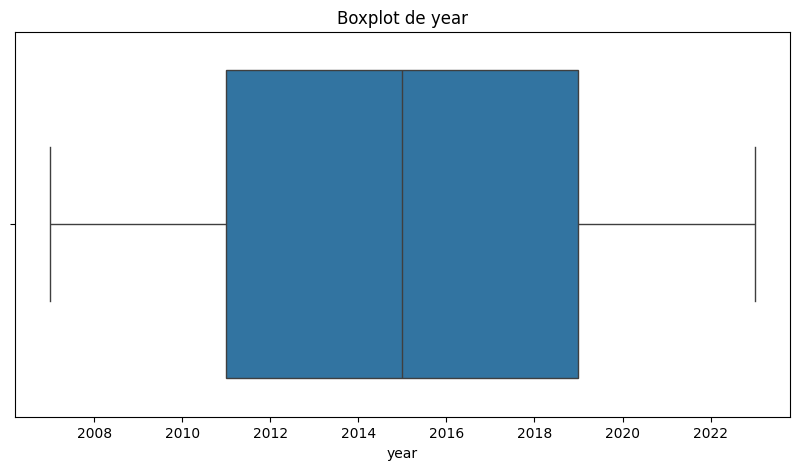

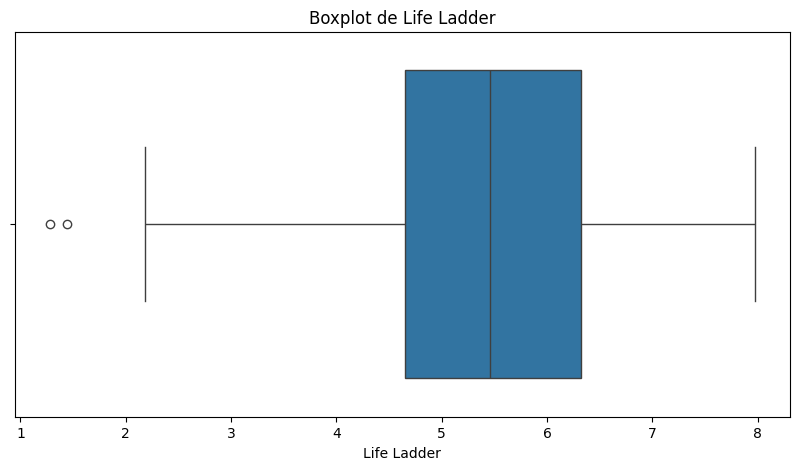

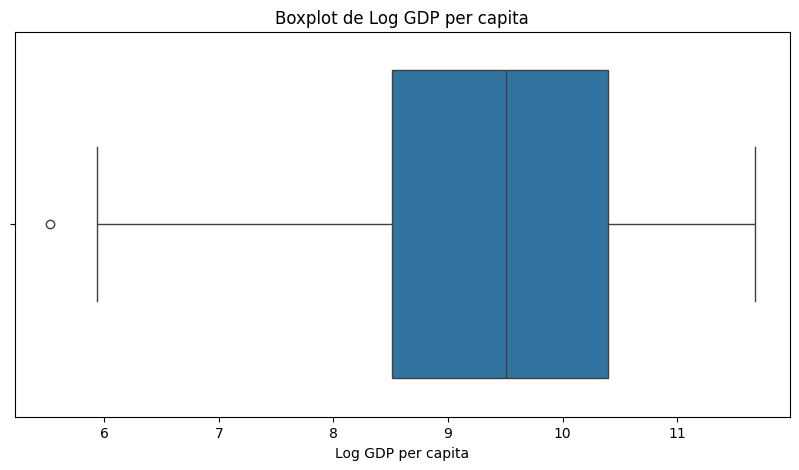

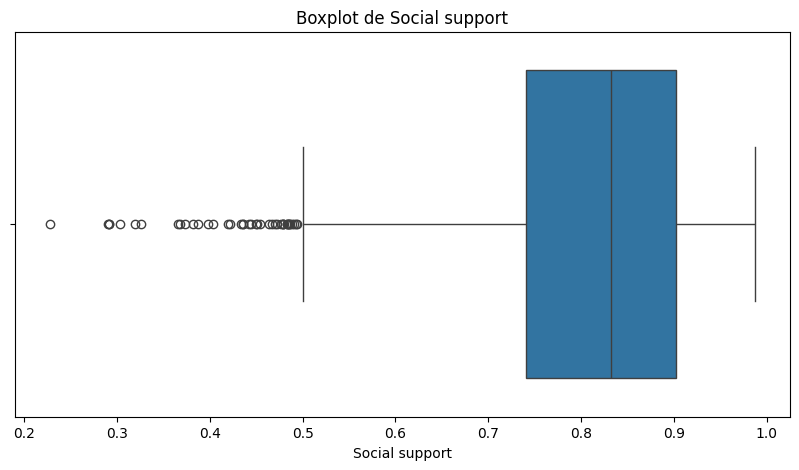

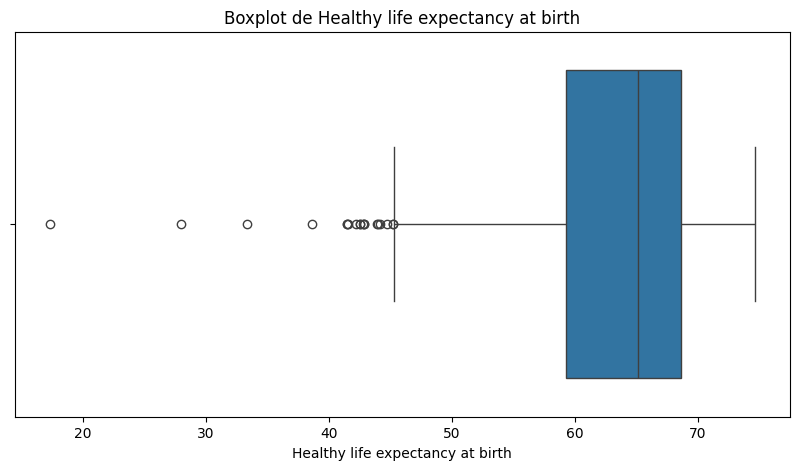

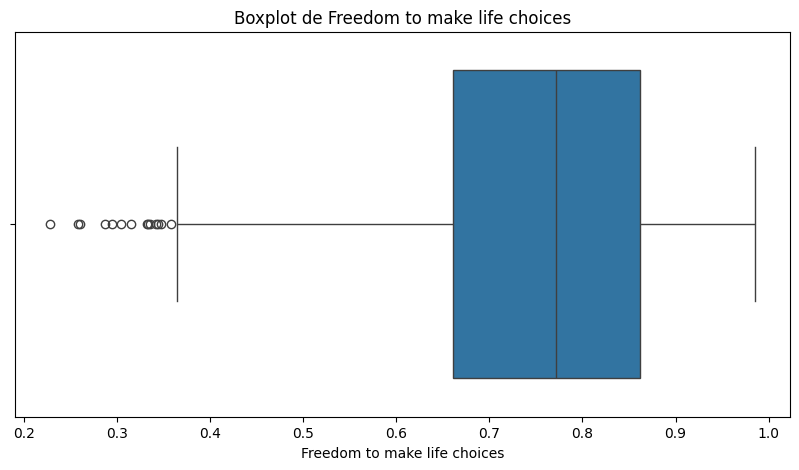

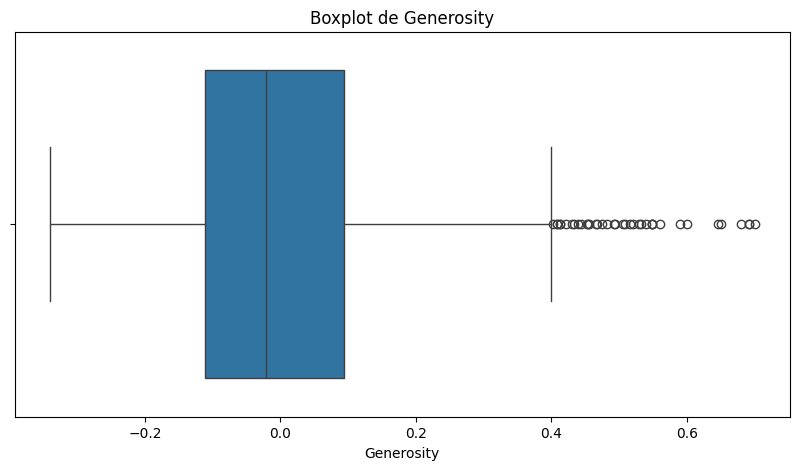

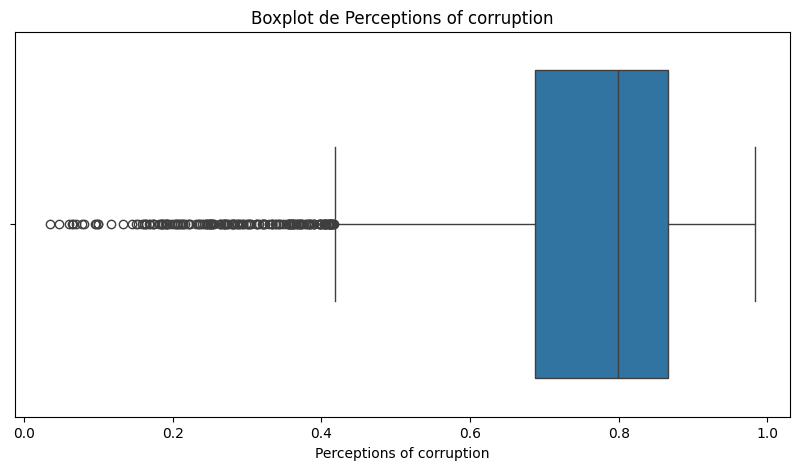

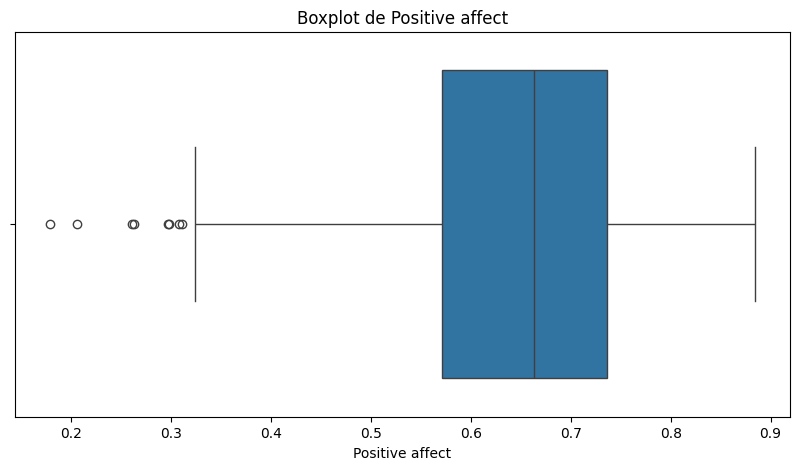

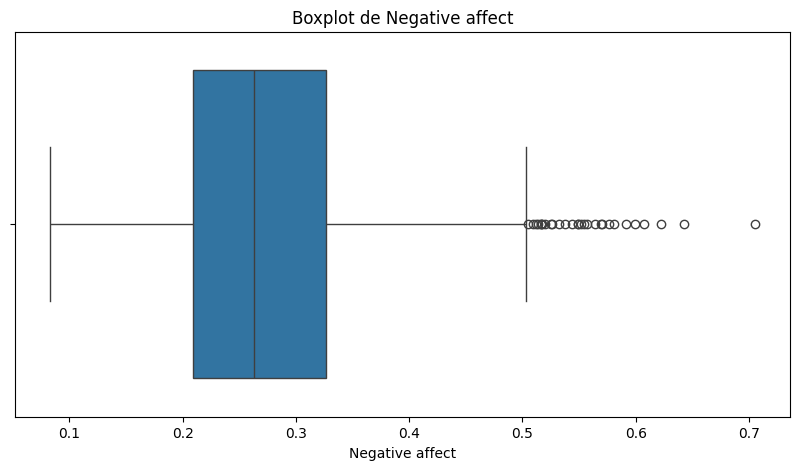

In [ ]:
# analisando boxplots das colunas numéricas

numerica_cols = df.select_dtypes(include = np.number)

for column in numerica_cols:
  plt.figure(figsize=(10,5))
  sns.boxplot(x=df[column], orient='h')
  plt.title(f'Boxplot de {column}')
  plt.show()

## Análise dos Boxplots

Os boxplots fornecem uma boa visão geral das distribuições de diversas variáveis na nossa base de dados. A seguir, analisamos cada uma delas:

1. Life Ladder
    
      O boxplot de Life Ladder revela que a maioria das pontuações de felicidade estão concentradas entre 4,7 e 6,3, com a mediana em torno de 5,5. Esses valores indicam uma tendência de felicidade relativamente baixa para a maioria dos casos na base de dados.

2. Log GDP per capita
    
      Para o Log GDP per capita, a distribuição está concentrada entre 8,5 e 10,4, com a mediana próxima a 9,5, sugerindo que a maioria dos países da base de dados têm PIB per capita dentro dessa faixa.

3. Social Support
    
      O boxplot de Social Support mostra que a maioria dos valores estão entre 0,74 e 0,91, com uma mediana em 0,83. No entanto, há uma quantidade significativa de outliers abaixo da cerca inferior, indicando a presença de valores extremos.

4. Healthy life expectancy at birth
      
      Para Healthy life expectancy at birth, a maioria dos valores está entre 59 e 68 anos, com uma mediana de 65 anos. Similarmente, observamos outliers abaixo da cerca inferior, que indicam valores extremos mais baixos.

5. Freedom to make life choices
    
      A variável Freedom to make life choices mostra a maioria dos valores entre 0,67 e 0,87, com uma mediana em torno de 0,78. Assim como nas outras variáveis, há outliers abaixo da cerca inferior.

6. Generosity
    
      O boxplot de Generosity revela que a maioria dos valores está entre -0,13 e +0,09, com a mediana em -0,02. Há também a presença de outliers significativos acima da cerca superior, sugerindo valores extremos altos.

7. Perceptions of corruption
    
      A variável Perceptions of corruption apresenta a maioria dos valores entre 0,68 e 0,87, com uma mediana de cerca de 0,8, embora existam outliers abaixo da cerca inferior.

8. Positive affect
    
      No boxplot de Positive affect, a maioria dos valores está entre 0,57 e 0,73, com uma mediana em torno de 0,67. Também são observados alguns outliers abaixo da cerca inferior.

9. Negative affect
    
      Por fim, para Negative affect, a maioria dos valores está entre 0,21 e 0,33, com a mediana em 0,27. No entanto, a presença de outliers acima da cerca superior também é notável.
    

### Presença de Outliers e Decisão sobre o Tratamento de Valores Nulos

Uma análise comum em boxplots é a presença de outliers, que impacta diretamente a forma como lidamos com dados extremos e valores nulos. Observamos que várias variáveis apresentam outliers consideráveis, o que pode distorcer medidas como a média.

Devido a isso, decidimos utilizar a mediana para o tratamento de valores nulos. A mediana, ao contrário da média, não é sensível a valores extremos e fornece uma representação mais robusta da tendência central dos dados.

In [ ]:
# Substituindo valores nulos pela mediaan
imputermediana = SimpleImputer(strategy='median')
df[numerica_cols.columns] = imputermediana.fit_transform(df[numerica_cols.columns])

df.isnull().sum()   #para garantir que não temos mais valores nulos

,0
Country name,0
year,0
Life Ladder,0
Log GDP per capita,0
Social support,0
Healthy life expectancy at birth,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0
Positive affect,0


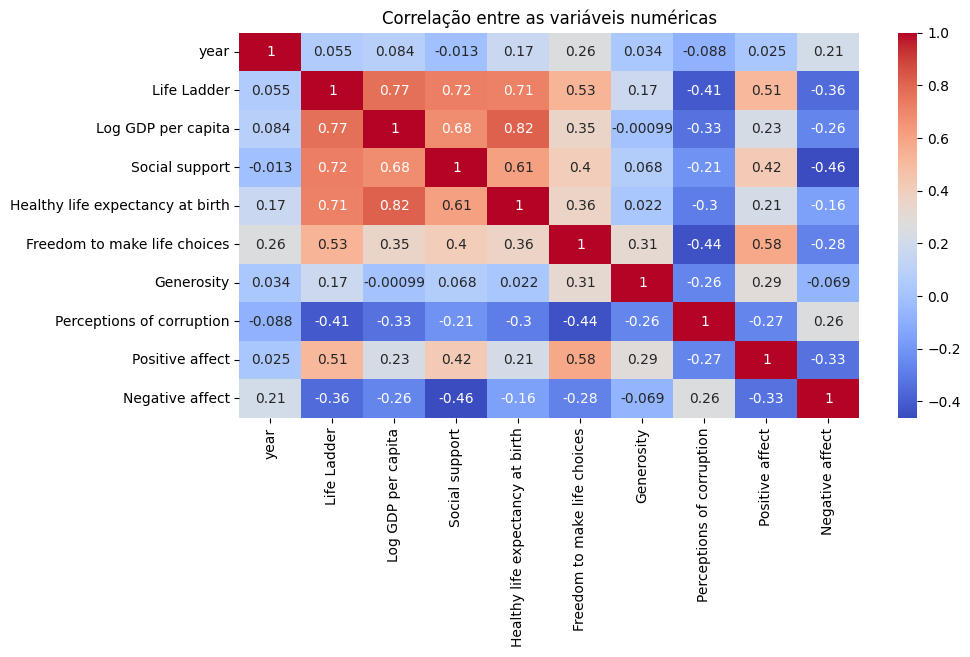

In [ ]:
# analisando matriz de correlação
correlation_matrix = df[numerica_cols.columns].corr()

plt.figure(figsize=(10,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlação entre as variáveis numéricas')
plt.show()

## Análise da Matriz de Correlação

Com a análise da matriz de correlação, podemos tirar que os 12 pares mais correlacionados são:

1. Healthy life expectancy at birth e Log GPD per capita = 0,82
2. Life Ladder e Log GPD per capita = 0,77
3. Life Ladder e Social Support = 0,72
4. Healthy life expectancy at birth e Life Ladder = 0,71
5. Log GPD per capita e Social support = 0,68
6. Healthy life expectancy at birth e Social support = 0,61
7. Freedom to make life choices e Positive affect = 0,58
8. Freedom to make life choices e Life Ladder = 0,53
9. Life Ladder e Positive affect = 0,51
10. Negative affect e Social support = -0,46
11. Freedom to make life choices e Perceptions of corruption = -0,44
12. Life Ladder e Perceptions of corruption = -0,41


Os 9 primeiros pares tem correlação positiva, o que indica que as duas variáveis tendem a se mover na mesma direção. Os 3 últimos tem uma correlação negativa, o que significa que as duas variáveis tendem a se mover em direções opostas.

Além disso, a partir dessa análise podemos tirar algumas variáveis que tem forte correlação direta com o atributo de **Life Ladder** (que representa a pontuação de felicidade de um país de 0 a 10):
1. Log GPD per capita (0,77)
2. Social support (0,72)
3. Healthy life expectancy at birth (0,71)
4. Freedom to make life choices (0,53)
5. Positive affect (0,51)
6. Perceptions of corruption (-0,41)

# Análise da Felicidade na Atualidade
# PERGUNTA 1:
# Que países do mundo foram mais e menos felizes durante o período da Pandemia?

In [ ]:
import plotly.express as px   #para criar um mapa
import numpy as np

df_recent_years = df[df['year'].between(2020, 2023)]

# Agrupando pelos países e regiões e calculando a média do Life Ladder
df_avg_ladder = df_recent_years.groupby(['Country name', 'Regional indicator'])['Life Ladder'].mean().reset_index()


# Média e mediana da felicidade dos países
media_felicidade_atual = df_avg_ladder['Life Ladder'].mean()
print(f"Média da felicidade (2020-2023): {media_felicidade_atual}")
mediana_felicidade_atual = df_avg_ladder['Life Ladder'].median()
print(f"Mediana da felicidade (2020-2023): {mediana_felicidade_atual}")


 # Vermelho, Amarelo, Verde
custom_color_scale = ['#d62728', '#ffff00', '#2ca02c']

# mapa mundi
fig = px.choropleth(df_avg_ladder,
                    locations='Country name',
                    locationmode='country names',
                    color='Life Ladder',
                    color_continuous_scale=custom_color_scale,
                    title="Felicidade Média (2020-2023)")
fig.update_layout(
    title={
        'x': 0.5,  # Centraliza o título
        'xanchor': 'center'  # Define o ancoramento do título
    }
)

fig.show()

# 10 maiores
top_10_countries = df_avg_ladder.nlargest(10, 'Life Ladder')[['Country name', 'Life Ladder']]

# 10 menores
bottom_10_countries = df_avg_ladder.nsmallest(10, 'Life Ladder')[['Country name', 'Life Ladder']]

# Imprimindo os resultados
print("--- ANÁLISE DA FELICIDADE NA ATUALIDADE (2020-2023) ---")
print("10 países com os maiores valores da Life ladder:")
print(top_10_countries)

print("\n10 países com os menores valores da Life ladder:")
print(bottom_10_countries)


Média da felicidade (2020-2023): 5.526596736596736
Mediana da felicidade (2020-2023): 5.713


--- ANÁLISE DA FELICIDADE NA ATUALIDADE (2020-2023) ---
10 países com os maiores valores da Life ladder:
    Country name  Life Ladder
40       Finland      7.77775
32       Denmark      7.56575
53       Iceland      7.53775
94   Netherlands      7.36575
122       Sweden      7.33625
59        Israel      7.30450
100       Norway      7.29900
123  Switzerland      7.17225
77    Luxembourg      7.12200
95   New Zealand      7.08625

10 países com os menores valores da Life ladder:
         Country name  Life Ladder
0         Afghanistan      1.72100
72            Lebanon      2.68825
73            Lesotho      3.18600
113      Sierra Leone      3.24700
27   Congo (Kinshasa)      3.29500
142          Zimbabwe      3.29575
14           Botswana      3.38350
79             Malawi      3.42100
38           Eswatini      3.50200
140             Yemen      3.56100


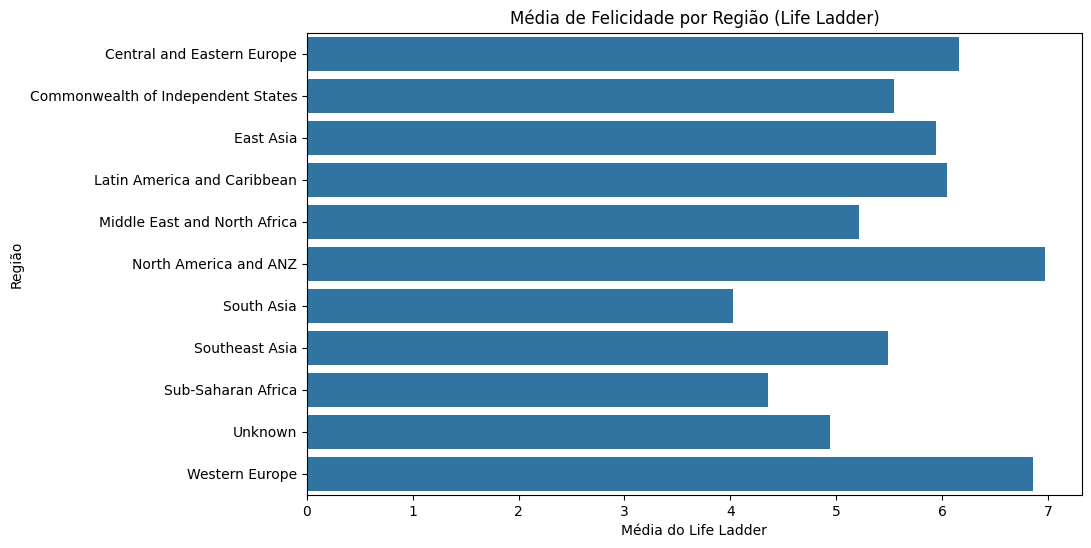

In [ ]:
# df da média de cada região
df_avg_ladder_per_region = df_avg_ladder.groupby('Regional indicator')['Life Ladder'].mean().reset_index()

# Criando o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_avg_ladder_per_region, x='Life Ladder', y='Regional indicator')
plt.xlabel('Média do Life Ladder')
plt.ylabel('Região')
plt.title('Média de Felicidade por Região (Life Ladder)')
plt.show()

O mapa acima representa a média dos índice "Life Ladder" registrados entre 2020 e 2023, oferecendo uma boa representação do estado da felicidade de cada país em um tempo recente.

Estados Unidos, Canadá, Austrália e Nova Zelândia apresentam um índice de felicidade elevado, girando em torno de 7. Países europeus também possuem um bom índice de felicidade, com destaque para Dinamarca, Finlândia, Holanda, Islândia, Luxemburgo, Noruega, Suécia e Suiça, todos possuindo uma média acima de 7.

Países da América Latina, do leste e do sudeste asiático possuem um índice de felicidade intermediário, obtendo um score próximo a 6

É perceptível uma concentração de países com baixo índice de felicidade na África e no sul da Ásia, com destaque para o Afeganistão, que apresentou a menor média de índice de felicidade no período analisado do mundo





# PERGUNTA 2: Impacto da Pandemia da COVID-19 na felicidade
### A pandemia impactou na felicidade dos países?

Para analisar o impacto da pandemia da COVID-19 na felicidade dos países, iremos considerar os de 2018 e 2019 como pré-pandemia e 2020 e 2021 como pós início da pandemia. Sendo assim, iremos calcular a diferença do nível de felicidade entre esses períodos, dada pela fórmula:

LadderScore_PréPandemia = (LadderScore2018 + LadderScore2019) / 2

LadderScore_PósPandemia = (LadderScore2020 + LadderScore2021) / 2

**Diferença = LadderScore_PósPandemia - LadderScore_PréPandemia**

Sendo assim, se:


*   **Diferença > 0**: País tornou-se mais feliz após a pandemia
*   **Diferença < 0**: País tornou-se menos feliz após a pandemia




In [ ]:
# Separando os dados antes e depois da pandemia
df_pre_pandemia = df[(df['year'] >= 2018) & (df['year'] <= 2019)]
df_pos_pandemia = df[(df['year'] >= 2020) & (df['year'] <= 2021)]


In [ ]:
# Calculando a média do Ladder Score antes da pandemia (2018-2019)
media_pre_pandemia = df_pre_pandemia.groupby(['Country name', 'Regional indicator'])['Life Ladder'].mean().reset_index(name='Media_Pre_Pandemia')

# Calculando a média do Ladder Score após a pandemia (2020-2021)
media_pos_pandemia = df_pos_pandemia.groupby(['Country name', 'Regional indicator'])['Life Ladder'].mean().reset_index(name='Media_Pos_Pandemia')

# Mesclando as médias em um único DataFrame para comparar
df_comparacao = pd.merge(media_pre_pandemia, media_pos_pandemia, on='Country name', how='inner')


In [ ]:
df_comparacao.head(5)

,Country name,Regional indicator_x,Media_Pre_Pandemia,Regional indicator_y,Media_Pos_Pandemia
0,Afghanistan,South Asia,2.5345,South Asia,2.4360
1,Albania,Central and Eastern Europe,4.9995,Central and Eastern Europe,5.3100
2,Algeria,Middle East and North Africa,4.8940,Middle East and North Africa,5.3275
3,Argentina,Latin America and Caribbean,5.9395,Latin America and Caribbean,5.9045
4,Armenia,Commonwealth of Independent States,5.2750,Commonwealth of Independent States,5.3010


In [ ]:
# Calculando a diferença entre as médias
df_comparacao['Diferenca_Ladder_Score'] = df_comparacao['Media_Pos_Pandemia'] - df_comparacao['Media_Pre_Pandemia']

# Renomeando a coluna duplicada para 'Regional indicator'
df_comparacao.rename(columns={'Regional indicator_y': 'Regional indicator'}, inplace=True)

# Removendo a coluna 'Regional indicator_x', pois ela agora é redundante
df_comparacao.drop(columns=['Regional indicator_x'], inplace=True)


In [ ]:
df_comparacao.head(5)


,Country name,Media_Pre_Pandemia,Regional indicator,Media_Pos_Pandemia,Diferenca_Ladder_Score
0,Afghanistan,2.5345,South Asia,2.4360,-0.0985
1,Albania,4.9995,Central and Eastern Europe,5.3100,0.3105
2,Algeria,4.8940,Middle East and North Africa,5.3275,0.4335
3,Argentina,5.9395,Latin America and Caribbean,5.9045,-0.0350
4,Armenia,5.2750,Commonwealth of Independent States,5.3010,0.0260


In [ ]:
# Média e mediana da diferença na felicidade dos países
media_diferenca = df_comparacao['Diferenca_Ladder_Score'].mean()
print(f"Média da diferença do Life Ladder por paíse pré e pós pandemia: {media_diferenca}")
mediana_diferenca = df_comparacao['Diferenca_Ladder_Score'].median()
print(f"Mediana da Diferença do Life Ladder por país pré e pós pandemia: {mediana_diferenca}")

# Calculando o valor absoluto máximo para tornar a escala simétrica
max_abs_diff = max(abs(df_comparacao['Diferenca_Ladder_Score'].min()), abs(df_comparacao['Diferenca_Ladder_Score'].max()))

# Mapa mundi
fig = px.choropleth(
    df_comparacao,
    locations='Country name',
    locationmode='country names',
    color='Diferenca_Ladder_Score',
    color_continuous_scale='RdBu',  # Paleta divergente com azul e vermelho
    range_color=[-max_abs_diff, max_abs_diff],  # Escala simétrica em torno de 0
    title="Diferença da Felicidade Pré e Pós COVID-19",
    color_continuous_midpoint=0  # Define 0 como ponto médio
)


fig.update_layout(
    title={
        'x': 0.5,  # Centraliza o título
        'xanchor': 'center'  # Define o ancoramento do título
    }
)

fig.show()

# 10 maiores
top_10_countries = df_comparacao.nlargest(10, 'Diferenca_Ladder_Score')[['Country name', 'Diferenca_Ladder_Score']]

# 10 menores
bottom_10_countries = df_comparacao.nsmallest(10, 'Diferenca_Ladder_Score')[['Country name', 'Diferenca_Ladder_Score']]

# Imprimindo os resultados

print("10 países com os maior valor de diferença")
print(top_10_countries)

print("\n10 países com os menor valor diferença")
print(bottom_10_countries)



Média da diferença do Life Ladder por paíse pré e pós pandemia: -0.038784
Mediana da Diferença do Life Ladder por país pré e pós pandemia: -0.0034999999999998366


10 países com os maior valor de diferença
    Country name  Diferenca_Ladder_Score
24       Croatia                  0.8165
20         China                  0.6795
66      Malaysia                  0.6285
115      Ukraine                  0.6085
92       Romania                  0.5265
64     Lithuania                  0.4415
32       Estonia                  0.4405
2        Algeria                  0.4335
60    Kyrgyzstan                  0.4160
14      Bulgaria                  0.4065

10 países com os menor valor diferença
   Country name  Diferenca_Ladder_Score
63      Lebanon                 -2.1890
10        Benin                 -0.9475
7       Bahrain                 -0.9250
23   Costa Rica                 -0.6965
54      Jamaica                 -0.6895
21     Colombia                 -0.6675
16     Cambodia                 -0.5940
29      Ecuador                 -0.5740
89  Philippines                 -0.5460
56       Jordan                 -0.5445


In [ ]:
# Filtrando os países com 'Unknown' e 'Commonwealth of Independent States' no Regional indicator
unknown_countries = df_avg_ladder[df_avg_ladder['Regional indicator'] == 'Unknown']['Country name']
cois_countries = df_avg_ladder[df_avg_ladder['Regional indicator'] == 'Commonwealth of Independent States']['Country name']

# Imprimindo os nomes dos países
print("Países com Regional indicator = 'Unknown':")
print(unknown_countries)

print("Países com Regional indicator = 'Commonwealth of Independent States':")
print(cois_countries)


Países com Regional indicator = 'Unknown':
130    Türkiye
Name: Country name, dtype: object
Países com Regional indicator = 'Commonwealth of Independent States':
4         Armenia
7      Azerbaijan
44        Georgia
65     Kazakhstan
69     Kyrgyzstan
86        Moldova
109        Russia
125    Tajikistan
132       Ukraine
137    Uzbekistan
Name: Country name, dtype: object


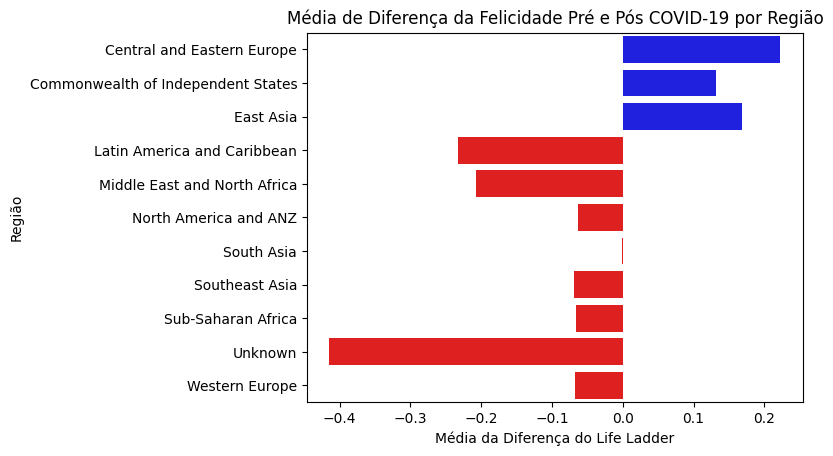

In [ ]:
# Analisando diferença por regiao
df_comparacao_media_por_regiao = df_comparacao.groupby('Regional indicator')['Diferenca_Ladder_Score'].mean().reset_index()

# Plotando o gráfico
bars = sns.barplot(
    data=df_comparacao_media_por_regiao,
    x='Diferenca_Ladder_Score',
    y='Regional indicator',
    hue='Diferenca_Ladder_Score',
    dodge=False,
    palette={k: 'red' if k < 0 else 'blue' for k in df_comparacao_media_por_regiao['Diferenca_Ladder_Score']}
)

# Removendo a legenda gerada pelo `hue`
bars.legend_.remove()

# Adicionando rótulos e título
plt.xlabel('Média da Diferença do Life Ladder')
plt.ylabel('Região')
plt.title('Média de Diferença da Felicidade Pré e Pós COVID-19 por Região')
plt.show()

In [ ]:
# Calculando a média do PIB per capita antes da pandemia (2018-2019)
media_PIB_pre_pandemia = df_pre_pandemia.groupby(['Country name', 'Regional indicator'])['Log GDP per capita'].mean().reset_index(name='Media_PIB_Pre_Pandemia')

# Calculando a média do PIB per capita após a pandemia (2020-2021)
media_PIB_pos_pandemia = df_pos_pandemia.groupby(['Country name', 'Regional indicator'])['Log GDP per capita'].mean().reset_index(name='Media_PIB_Pos_Pandemia')

# Mesclando as médias em um único DataFrame para comparar
df_comparacao_PIB = pd.merge(media_PIB_pre_pandemia, media_PIB_pos_pandemia, on='Country name', how='inner')

# Calculando a diferença entre as médias
df_comparacao_PIB['Diferenca_PIB'] = df_comparacao_PIB['Media_PIB_Pre_Pandemia'] - df_comparacao_PIB['Media_PIB_Pos_Pandemia']

# Renomeando a coluna duplicada para 'Regional indicator'
df_comparacao_PIB.rename(columns={'Regional indicator_y': 'Regional indicator'}, inplace=True)

# Removendo a coluna 'Regional indicator_x', pois ela agora é redundante
df_comparacao_PIB.drop(columns=['Regional indicator_x'], inplace=True)

# Juntando Diferenca_Ladder_Score e Diferenca_PIB no mesmo dataframe
df_analise = pd.merge(
    df_comparacao[['Country name', 'Regional indicator', 'Diferenca_Ladder_Score']],
    df_comparacao_PIB[['Country name', 'Diferenca_PIB']],
    on='Country name',
    how='inner'
)

#Calculando a correlação entre as variáveis
correlacao_ladder_pib = df_analise['Diferenca_Ladder_Score'].corr(df_analise['Diferenca_PIB'])

# Exibindo a correlação
print(f'Correlação entre "Diferença Ladder Score" e "Diferença PIB per capita": {correlacao_ladder_pib}')


Correlação entre "Diferença Ladder Score" e "Diferença PIB per capita": -0.011492129427631568


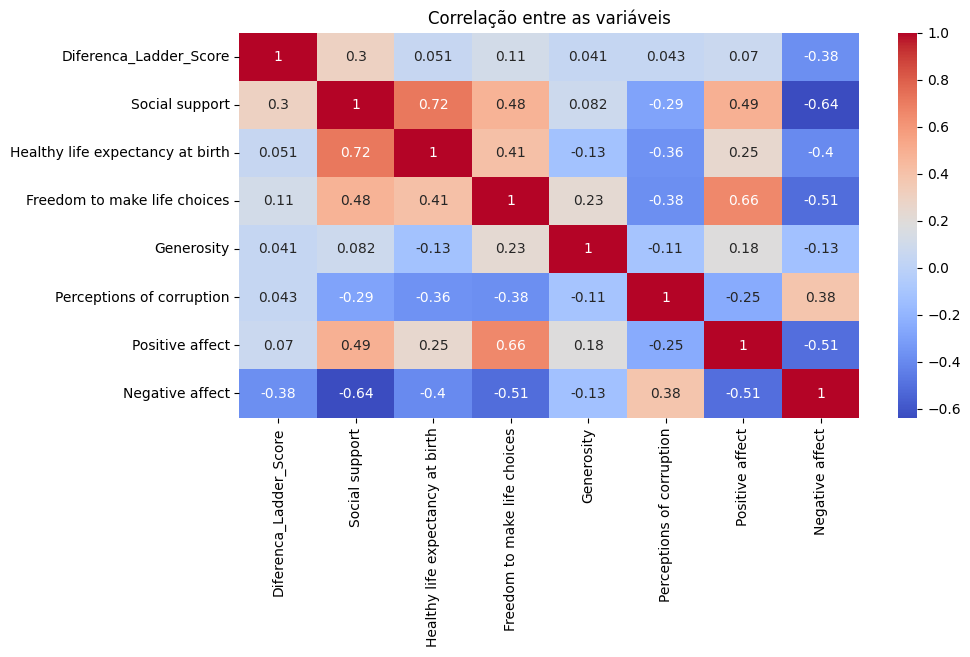

In [ ]:
# Variáveis a serem analisadas
variaveis_para_agregar = ['Social support', 'Healthy life expectancy at birth', 'Freedom to make life choices',
                          'Generosity', 'Perceptions of corruption', 'Positive affect', 'Negative affect']

# Fazendo média das variáveis no período pós-início da pandemia (2020-2021)
media_variaveis_pos_pandemia = df_pos_pandemia.groupby(['Country name', 'Regional indicator'])[variaveis_para_agregar].mean().reset_index()

# Criando dataframe com as variáveis selecionadas + alteração na felicidade
df_merge_comparacao = pd.merge(df_comparacao, media_variaveis_pos_pandemia, on=['Country name', 'Regional indicator'], how='inner')

# Drop de colunas não necessárias
df_merge_comparacao.drop(columns=['Media_Pre_Pandemia', 'Media_Pos_Pandemia'], inplace=True)

# Calculando correlação
numerica_cols = df_merge_comparacao.select_dtypes(include = np.number).columns
correlation_matrix = df_merge_comparacao[numerica_cols].corr()

# Gerando Matri de correlação
plt.figure(figsize=(10,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlação entre as variáveis')
plt.show()

In [ ]:
df_merge_comparacao

,Country name,Regional indicator,Diferenca_Ladder_Score,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,South Asia,-0.0985,0.4540,54.5500,0.3940,-0.0850,0.9460,0.1790,0.6070
1,Albania,Central and Eastern Europe,0.3105,0.7060,69.1375,0.7905,0.0205,0.8935,0.5585,0.2595
2,Algeria,Middle East and North Africa,0.4335,0.8545,66.5500,0.5660,-0.1200,0.7180,0.5110,0.2845
3,Argentina,Latin America and Caribbean,-0.0350,0.8895,67.1750,0.8210,-0.0725,0.8160,0.6820,0.3435
4,Armenia,Commonwealth of Independent States,0.0260,0.7620,67.6500,0.7950,-0.1590,0.7050,0.5660,0.4780
...,...,...,...,...,...,...,...,...,...,...
120,Uzbekistan,Commonwealth of Independent States,-0.1660,0.8730,65.1500,0.9275,0.1865,0.6520,0.6880,0.2560
121,Venezuela,Latin America and Caribbean,-0.2025,0.8085,64.1375,0.6040,-0.0220,0.8175,0.6935,0.3925
122,Vietnam,Southeast Asia,0.1195,0.7820,65.4500,0.9210,0.0835,0.7945,0.6750,0.2830
123,Zambia,Sub-Saharan Africa,0.2860,0.6930,55.0375,0.7915,0.0960,0.8170,0.6675,0.3470


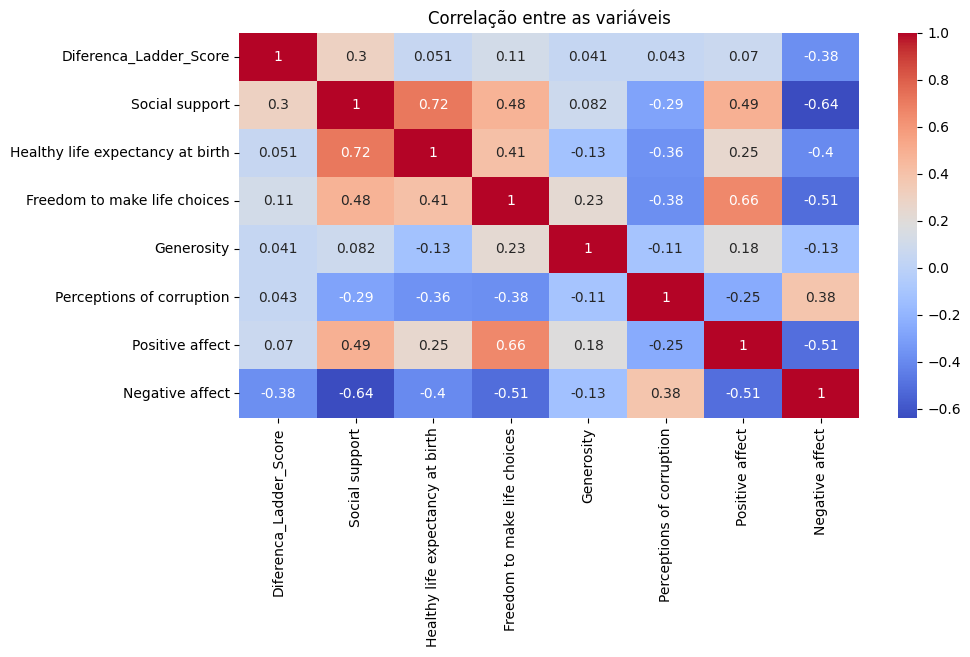

In [ ]:
numerica_cols = df_merge_comparacao.select_dtypes(include = np.number).columns

correlation_matrix = df_merge_comparacao[numerica_cols].corr()

plt.figure(figsize=(10,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlação entre as variáveis')
plt.show()

. A correlação positiva de 0,3 entre "Social support" e a alteração na felicidade sugere que o apoio social (ter um amigo ou familiar com quem contar) possa ter desempenhado um papel importante nos países que conseguiram tornar-se mais felizes durante a pandemia, mas sem implicar uma relação de causa e efeito direta. Isso reflete a importância de redes de apoio emocional na sensação de bem-estar e felicidade dos seres humanos.

● A  correlação negativa de -0,38 entre "Negative affect" e a alteração na felicidade, indica que possa existir uma relação entre a diminuição do índice da felicidade e a vivência de experiências negativas num período próximo à pesquisa por parte dos cidadãos que foram entrevistados. Como sabemos, a pandemia da COVID-19 gerou momentos de dificuldade na vida de muitas pessoas, e essa correlação sugere que tais experiências possam ter impactado a percepção de felicidade em alguns países.

#Tendência da Felicidade com Regressão Linear

Ao calcular a regressão linear para o índice de felicidade ao longo do tempo, foi possível estimar como a felicidade tem evoluído em diferentes países. O coeficiente da reta gerada pela regressão linear representa a taxa de mudança no índice de felicidade para cada país ao longo dos anos.

* **Coeficiente positivo:** Países com coeficientes positivos indicam uma tendência crescente na felicidade, ou seja, esses países têm apresentado uma melhora ao longo do tempo.
    
* **Coeficiente negativo:** Países com coeficientes negativos indicam uma tendência decrescente, ou seja, esses países têm se tornado progressivamente menos felizes.

Abaixo estão listados os **10 países com maior tendência de crescimento na felicidade**, ou seja, os que têm experimentado um aumento mais significativo na felicidade ao longo do tempo (coeficientes positivos):

1. Sérvia: coeficiente 2,13
2. Bulgária: coeficiente 1,96
3. Guiné: coeficiente 1,72
4. Romênia: coeficiente 1,71
5. Letônia: coeficiente 1,70
6. Togo: coeficiente 1,60
7. Hungria: coeficiente 1,58
8. República do Congo (Brazzaville): coeficiente 1,57
9. Costa do Marfim: coeficiente 1,53
10. Kosovo: coeficiente 1,49

Esses países têm mostrado uma melhora constante na felicidade, com os valores de felicidade aumentando ao longo dos anos.

Por outro lado, os **10 países com maior tendência de queda na felicidade** (coeficientes negativos) são:

1. Afeganistão: coeficiente -2,80
2. Síria: coeficiente -2,46
3. Líbano: coeficiente -2,42
4. Venezuela: coeficiente -2,10
5. Angola: coeficiente -1,74
6. Jordânia: coeficiente -1,71
7. Malawi: coeficiente -1,54
8. Lesoto: coeficiente -1,49
9. Zâmbia: coeficiente -1,39
10. Botsuana: coeficiente -1,28

Esses países estão apresentando uma diminuição significativa da felicidade ao longo dos anos, com os valores de felicidade caindo consistentemente.

**Importante:**

Vale destacar que esses coeficientes **não indicam os países mais felizes ou mais tristes em termos absolutos, mas sim os países com as maiores tendências de crescimento ou declínio no índice de felicidade ao longo do tempo**. Ou seja, um coeficiente positivo alto significa que a felicidade desses países tem aumentado mais rapidamente ao longo dos anos, enquanto um coeficiente negativo indica que a felicidade tem diminuído de forma mais acentuada.

In [ ]:
def calcular_tendencia(grupo):
  """Calcula a tendência da felicidade com base em todos os anos de registro"""
  """Regressão Linear"""
  anos = grupo.index.values

  felicidade = grupo['Life Ladder'].values

  # Verificando se há dados suficientes para o cálculo da tendência:
  if len(anos) < 2:  # Necessário pelo menos 2 pontos para calcular a tendência
    return np.nan

  # Normalizando os anos:
  anos_normalizados = (anos - anos.min()) / (anos.max() - anos.min())

  coeficientes = np.polyfit(anos_normalizados, felicidade, 1)
  return coeficientes[0]

df_tendencia = df.groupby('Country name')[['Life Ladder']].apply(calcular_tendencia).reset_index(name='Tendencia')

df_tendencia

,Country name,Tendencia
0,Afghanistan,-2.805400
1,Albania,0.043809
2,Algeria,-0.368091
3,Angola,-1.741500
4,Argentina,-0.284353
...,...,...
159,Venezuela,-2.073507
160,Vietnam,0.523255
161,Yemen,-1.088086
162,Zambia,-1.385382


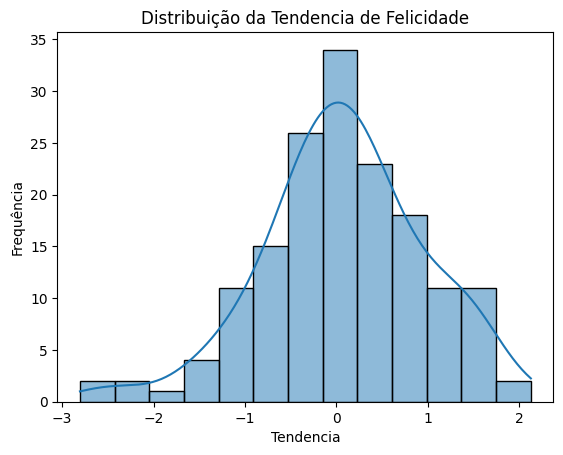

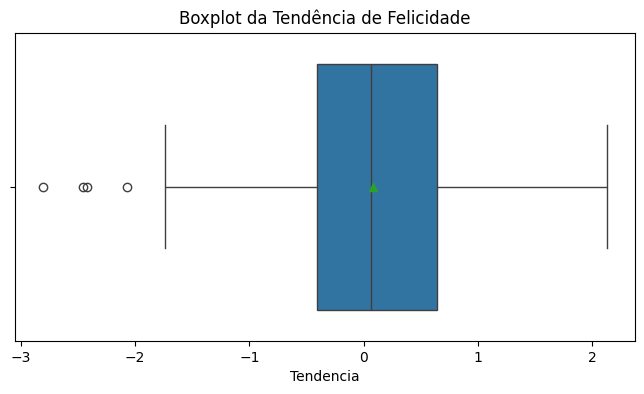

In [ ]:
sns.histplot(df_tendencia['Tendencia'], kde=True)
plt.xlabel('Tendencia')
plt.ylabel('Frequência')
plt.title('Distribuição da Tendencia de Felicidade')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df_tendencia['Tendencia'], orient='h', showmeans=True)
plt.title(f'Boxplot da Tendência de Felicidade')
plt.show()


Média da Tendência por país: 0.07808916143293076
Mediana da Tendência por país: 0.06136990950226231


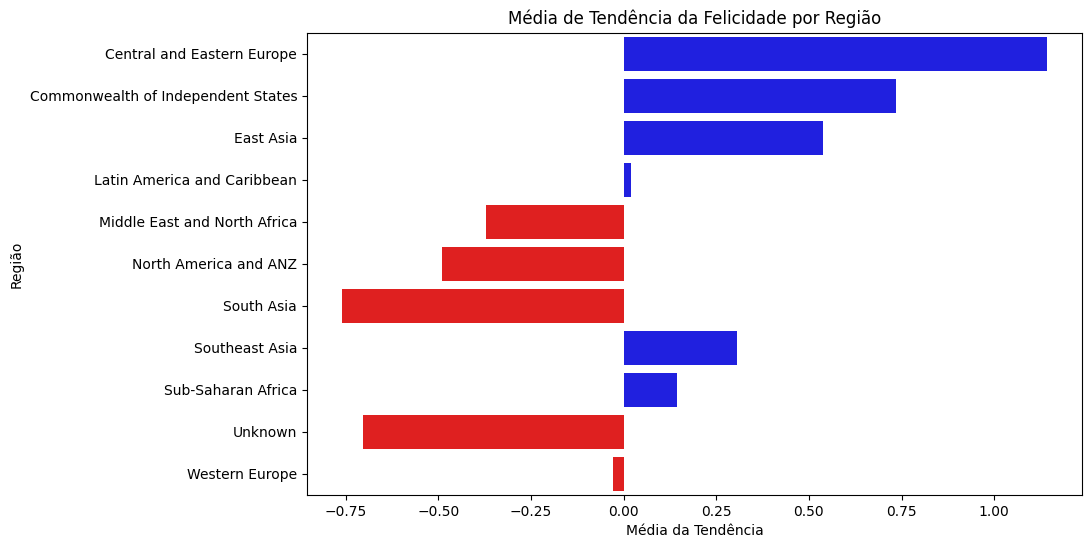

In [ ]:
import plotly.express as px
import pandas as pd

# Média e mediana da tendência da felicidade dos países
media_tendencia = df_tendencia['Tendencia'].mean()
print(f"Média da Tendência por país: {media_tendencia}")
mediana_tendencia = df_tendencia['Tendencia'].median()
print(f"Mediana da Tendência por país: {mediana_tendencia}")


# Mapa mundi
max_abs_diff = max(abs(df_tendencia['Tendencia'].min()), abs(df_tendencia['Tendencia'].max()))
fig = px.choropleth(df_tendencia,
                    locations='Country name',
                    locationmode='country names',
                    color='Tendencia',
                    color_continuous_scale='RdBu',
                    range_color=[-max_abs_diff, max_abs_diff],
                    color_continuous_midpoint=0,
                    title="Tendência da Felicidade")

# Ajustar a posição do título
fig.update_layout(
    title={
        'x': 0.5,
        'xanchor': 'center'
    },
    coloraxis_colorbar_tickvals=[df_tendencia['Tendencia'].min(), 0, df_tendencia['Tendencia'].max()],
)

fig.show()


# Mostrando média das tendências por região
df_tendencia_por_regiao = pd.merge(df_tendencia, df_regioes, on="Country name", how="left")
df_tendencia_por_regiao["Regional indicator"] = df_tendencia_por_regiao["Regional indicator"].fillna("Unknown")

unknown_countries = df_tendencia_por_regiao[df_tendencia_por_regiao['Regional indicator'] == 'Unknown']['Country name']

df_tendencia_por_regiao = df_tendencia_por_regiao.groupby('Regional indicator')['Tendencia'].mean().reset_index()

# Criando o gráfico
plt.figure(figsize=(10, 6))

# Plotando o gráfico
bars = sns.barplot(
    data=df_tendencia_por_regiao,
    x='Tendencia',
    y='Regional indicator',
    hue='Tendencia',  # Usando Tendencia como hue para associar as cores
    dodge=False,  # Evitar deslocamento das barras
    palette={k: 'red' if k < 0 else 'blue' for k in df_tendencia_por_regiao['Tendencia']}
)

# Removendo a legenda gerada pelo `hue`
bars.legend_.remove()

# Adicionando rótulos e título
plt.xlabel('Média da Tendência')
plt.ylabel('Região')
plt.title('Média de Tendência da Felicidade por Região')
plt.show()


In [ ]:
print(unknown_countries)

3                        Angola
11                      Belarus
13                       Belize
15                       Bhutan
22                      Burundi
26     Central African Republic
39                     Djibouti
57                       Guyana
58                        Haiti
90                     Maldives
111                        Oman
119                       Qatar
122                      Rwanda
130                     Somalia
131           Somaliland region
134                 South Sudan
138                       Sudan
139                    Suriname
142                       Syria
148         Trinidad and Tobago
150                Turkmenistan
151                     Türkiye
Name: Country name, dtype: object


In [ ]:
top_10_tendencia_felicidade_positiva = df_tendencia.nlargest(10, 'Tendencia')

top_10_tendencia_felicidade_positiva

,Country name,Tendencia
125,Serbia,2.127000
20,Bulgaria,1.957800
56,Guinea,1.717187
120,Romania,1.711478
80,Latvia,1.699037
147,Togo,1.596091
61,Hungary,1.575243
32,Congo (Brazzaville),1.566286
70,Ivory Coast,1.529577
76,Kosovo,1.494353


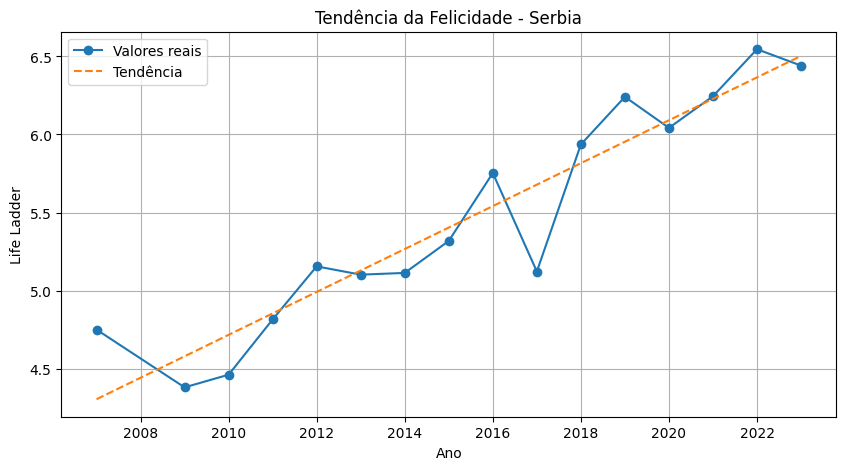

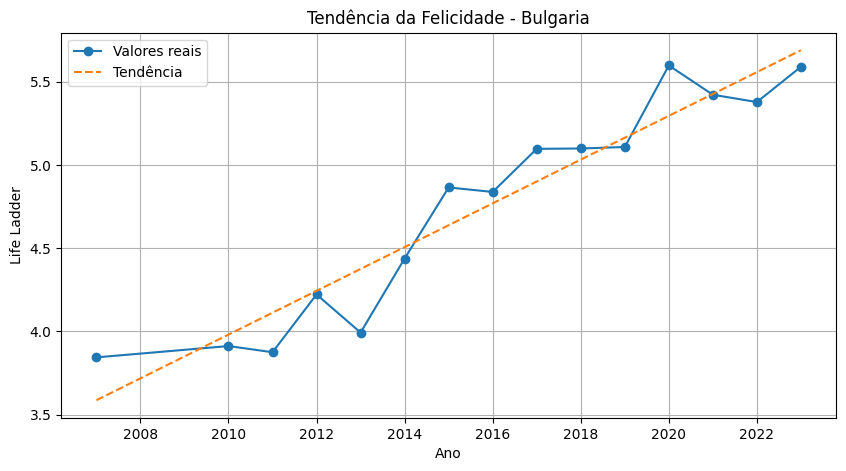

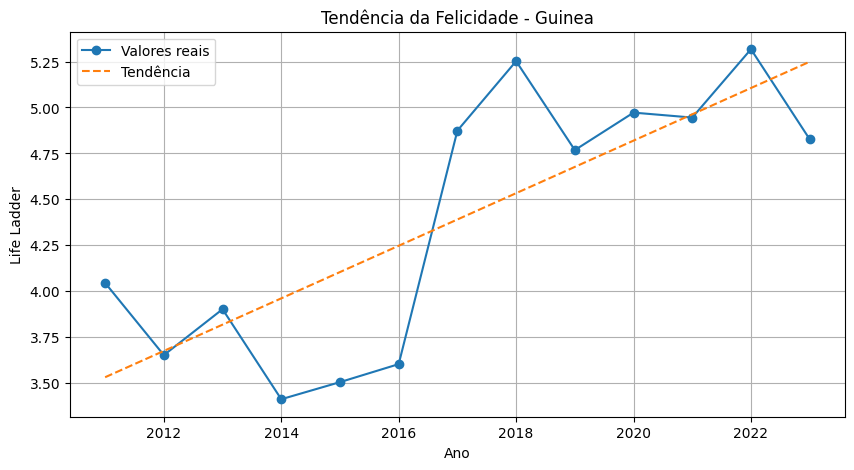

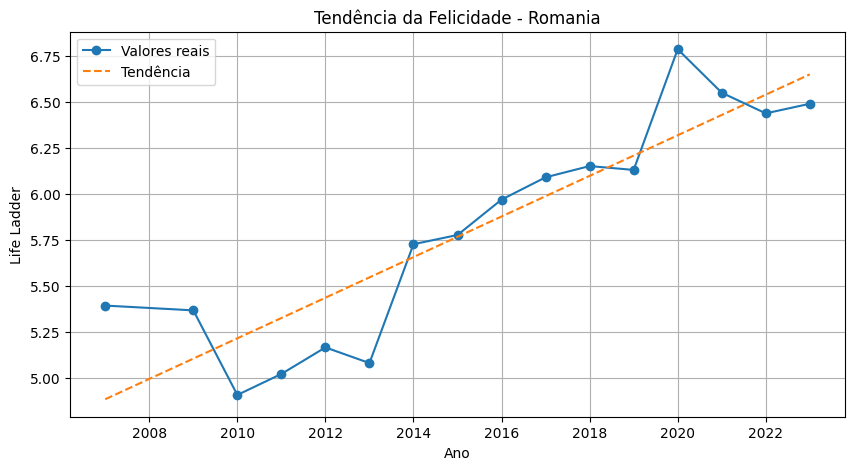

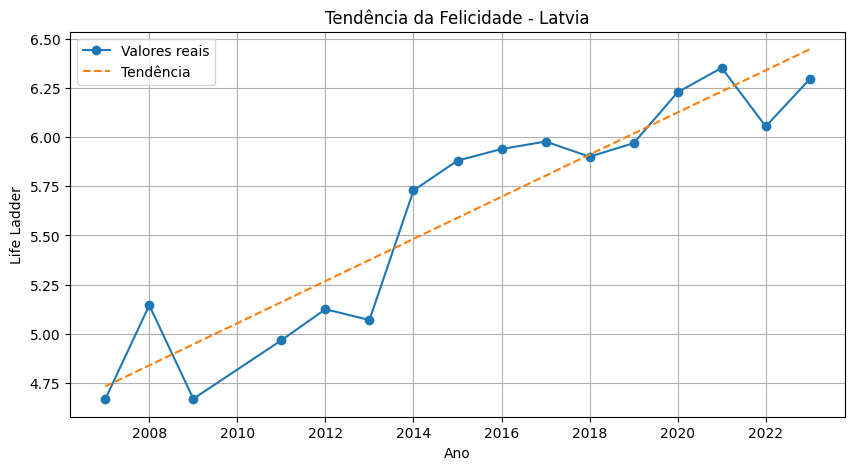

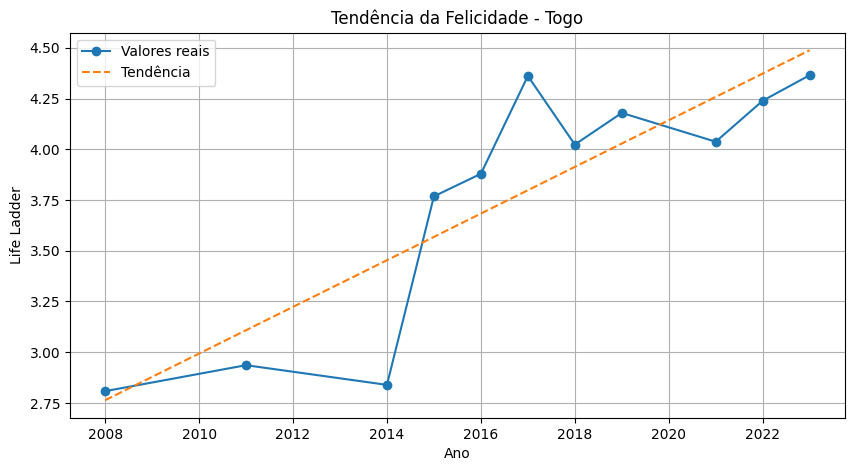

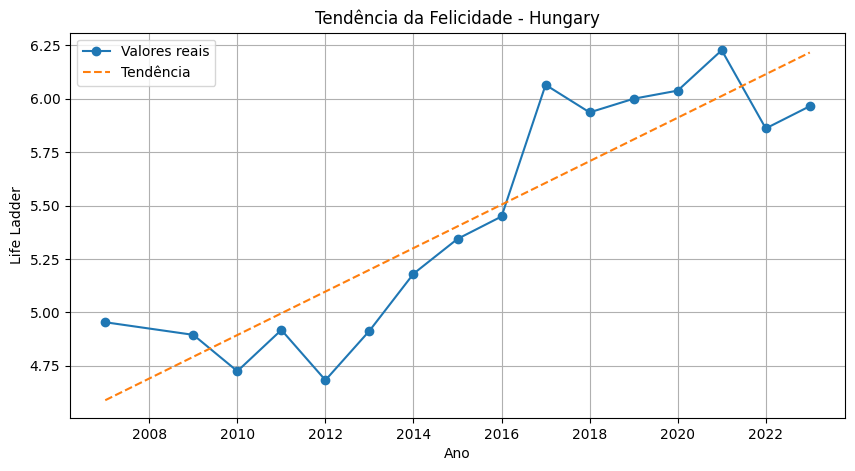

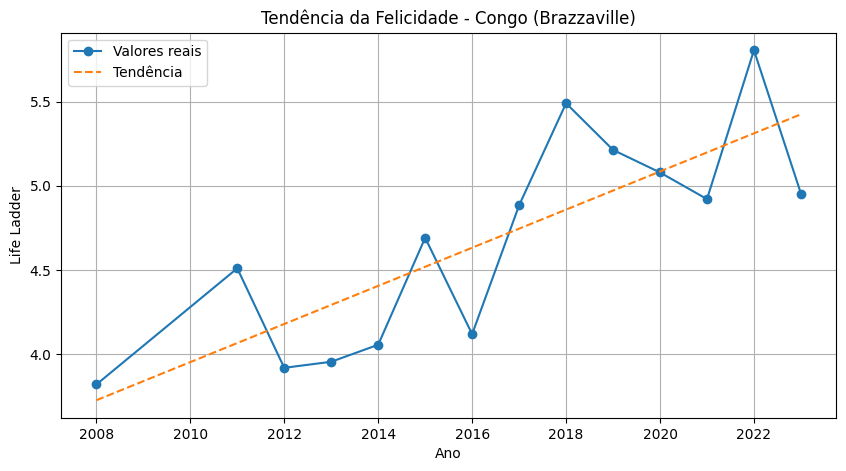

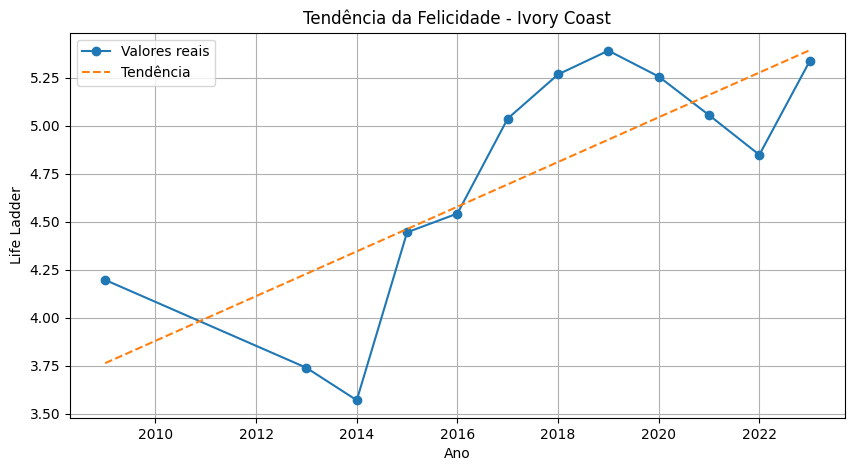

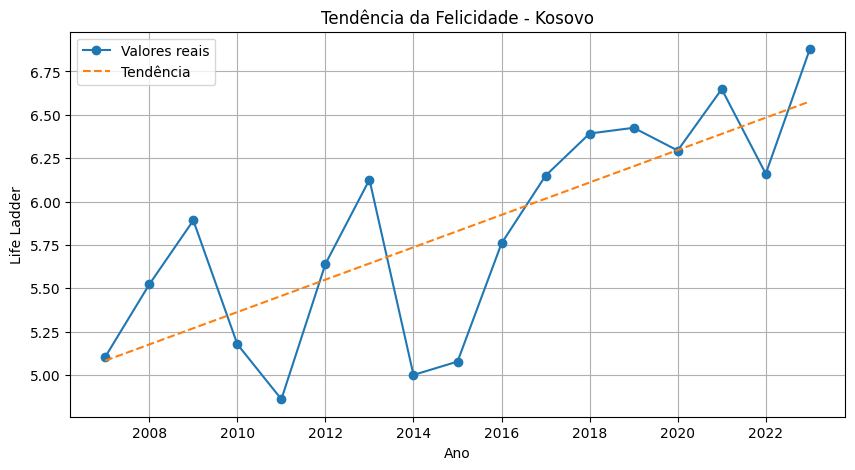

In [ ]:
for pais in top_10_tendencia_felicidade_positiva['Country name']:
    # Filtrar os dados do país
    dados_pais = df[df['Country name'] == pais]

    # Obter anos e valores de Life Ladder
    anos = dados_pais['year'].values
    felicidade = dados_pais['Life Ladder'].values

    # Calcular a reta de tendência
    coeficientes = np.polyfit(anos, felicidade, 1)
    tendencia = np.polyval(coeficientes, anos)

    # Criar o gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(anos, felicidade, marker='o', label='Valores reais')
    plt.plot(anos, tendencia, linestyle='--', label='Tendência')

    plt.title(f'Tendência da Felicidade - {pais}')
    plt.xlabel('Ano')
    plt.ylabel('Life Ladder')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
top_10_tendencia_felicidade_negativa = df_tendencia.nsmallest(10, 'Tendencia')

top_10_tendencia_felicidade_negativa


,Country name,Tendencia
0,Afghanistan,-2.805400
142,Syria,-2.457000
81,Lebanon,-2.418463
159,Venezuela,-2.073507
3,Angola,-1.741500
73,Jordan,-1.608039
88,Malawi,-1.535943
82,Lesotho,-1.488000
162,Zambia,-1.385382
18,Botswana,-1.279319


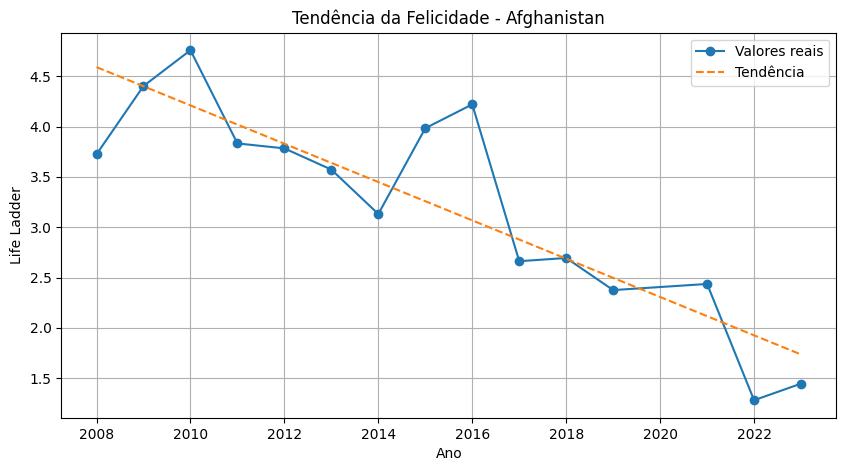

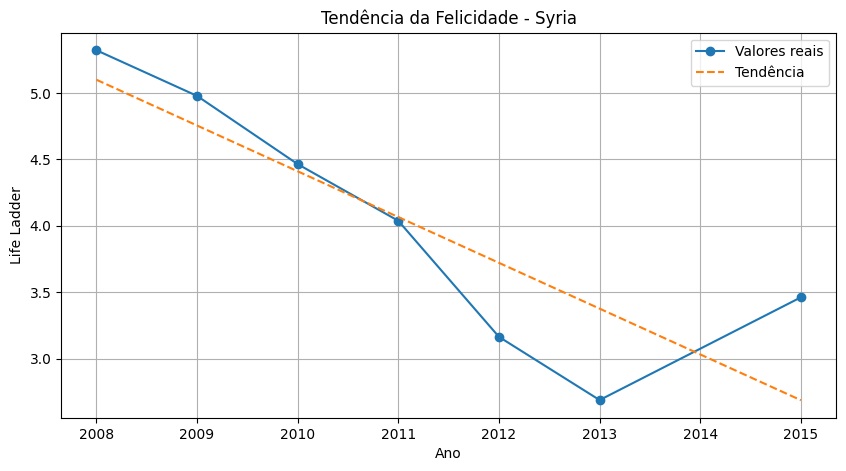

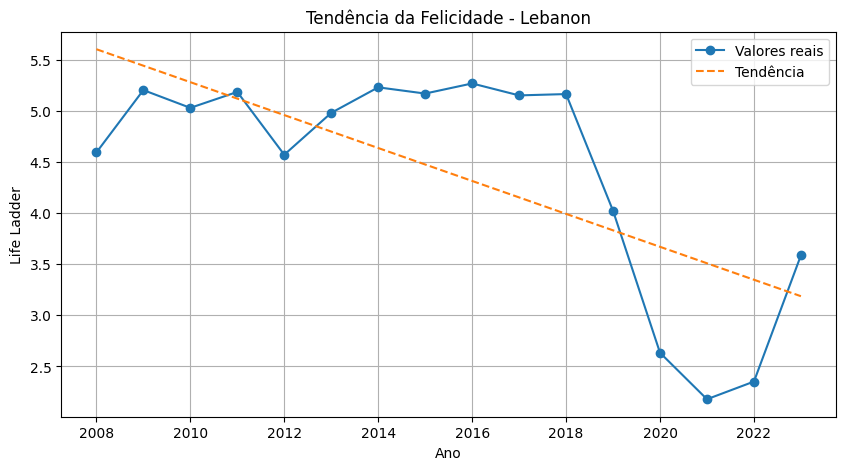

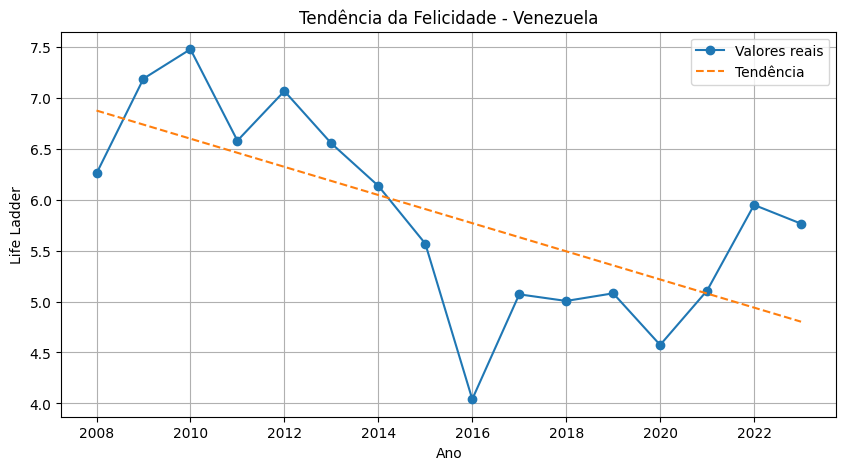

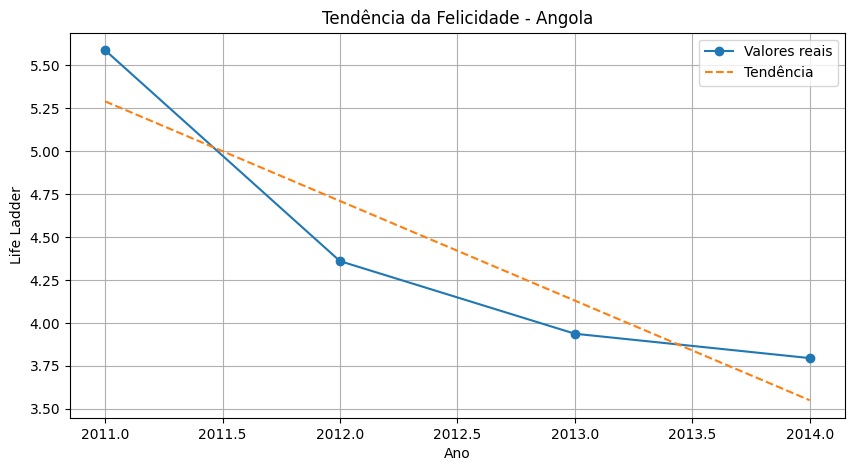

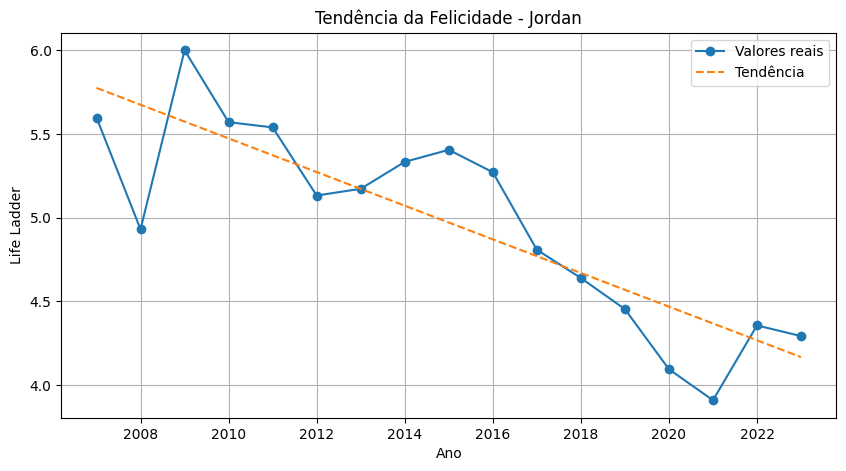

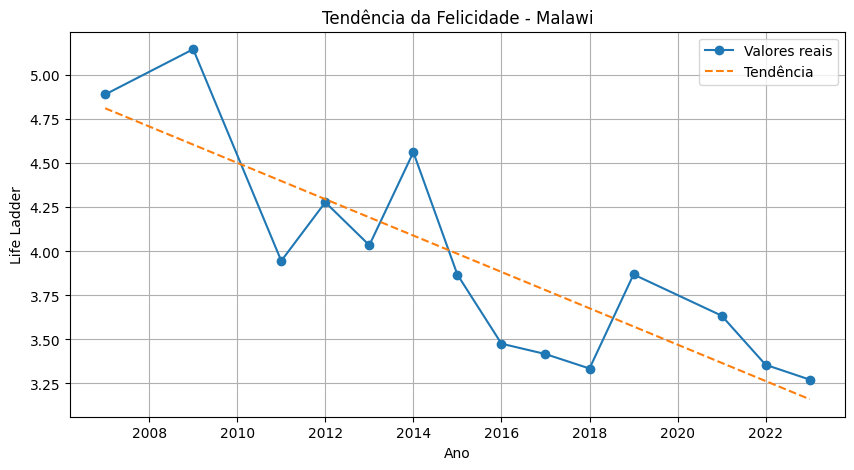

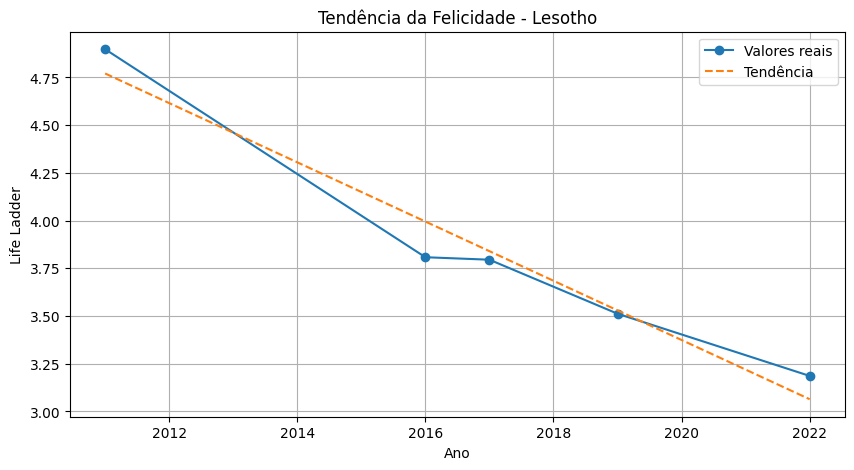

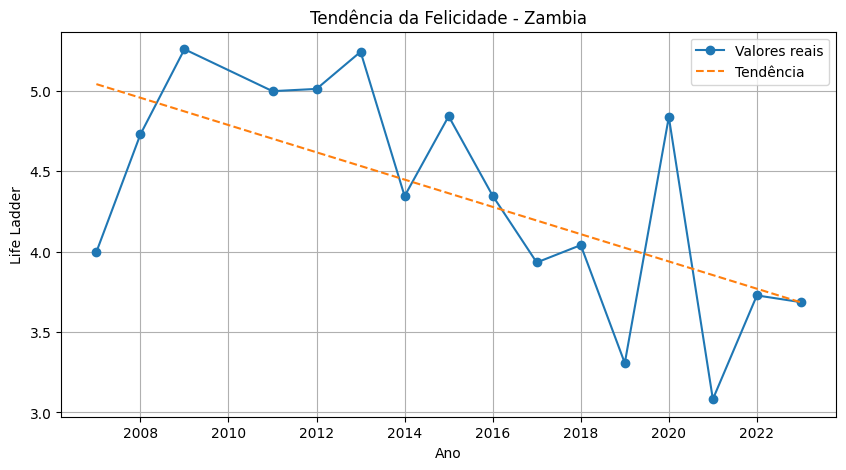

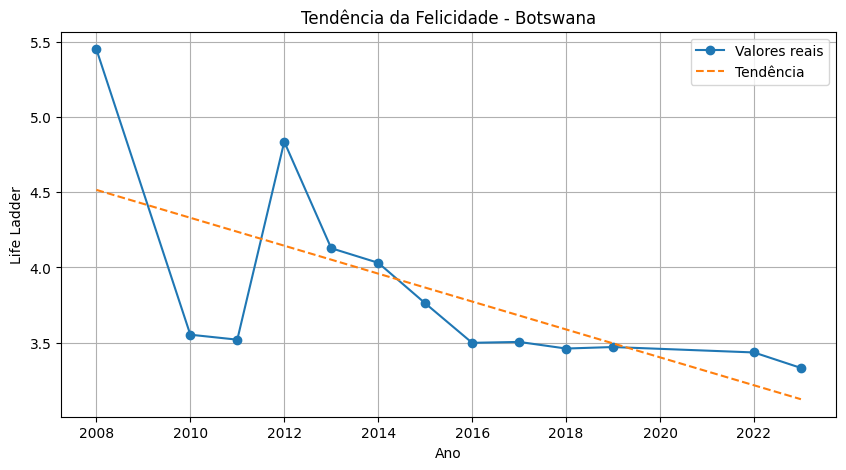

In [ ]:
for pais in top_10_tendencia_felicidade_negativa['Country name']:
    # Filtrar os dados do país
    dados_pais = df[df['Country name'] == pais]

    # Obter anos e valores de Life Ladder
    anos = dados_pais['year'].values
    felicidade = dados_pais['Life Ladder'].values

    # Calcular a reta de tendência
    coeficientes = np.polyfit(anos, felicidade, 1)
    tendencia = np.polyval(coeficientes, anos)

    # Criar o gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(anos, felicidade, marker='o', label='Valores reais')
    plt.plot(anos, tendencia, linestyle='--', label='Tendência')

    plt.title(f'Tendência da Felicidade - {pais}')
    plt.xlabel('Ano')
    plt.ylabel('Life Ladder')
    plt.legend()
    plt.grid(True)
    plt.show()

# Aplicando modelos de aprendizado de máquina

Iremos aplicar 4 modelos de AM, sendo eles:



*   Regressão Linear
*   Random Forest
*   Árvore de Decisão
*   KNN

Primeiramente, aplicaremos esses modelos sem incluir o atributo 'Regional indicator' no treinamento.

In [ ]:
# Criando um novo dataframe que incluirá as regiões no modelo de aprendizado de máquina
df_regioes = df

## Sem inclusão de 'Regional indicator' no treinamento

Para isso, faremos o treinamento em cima do DataFrame 'df'

In [ ]:
from sklearn.preprocessing import MinMaxScaler


# Aplicando normalização dos dados numéricos
cols_para_normalizar = ['Log GDP per capita', 'Social support', 'Healthy life expectancy at birth',
                       'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'
                       , 'Positive affect', 'Negative affect']

scaler = MinMaxScaler()

df[cols_para_normalizar] = scaler.fit_transform(df[cols_para_normalizar])

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df.drop(['Country name', 'year', 'Life Ladder', 'Regional indicator'], axis=1)
y = df['Life Ladder']

# Divisão dos conjuntos utilizado somente para análises de atributos no Random Forest
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# OBS: A separação treino-teste no treinamento dos modelos será feita utilizando K-Fold

### Utilizando Regressão Linear

In [ ]:
#### USANDO REGRESSÃO LINEAR COM  K-FOLD
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# Configurando o modelo
lr_regressor = LinearRegression()

# Configurando K-Fold
k = 10  # Número de folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# R²
r2_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring='r2')

# MAE
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
mae_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring=mae_scorer)

# RMSE (Usando a função atualizada)
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)
rmse_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring=rmse_scorer)

# Exibindo os resultados
print(f'Média do R²: {r2_scores.mean():.5f}')

print(f'Média do MAE: {-mae_scores.mean():.5f}')

print(f'Média do RMSE: {-rmse_scores.mean():.5f}')


Média do R²: 0.76509
Média do MAE: 0.41326
Média do RMSE: 0.54191


### Utilizando Random Forest

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Configurando o modelo RandomForest
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Definindo o número de folds
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Listas para armazenar os resultados
r2_scores = []
mae_scores = []
rmse_scores = []

# Lista para armazenar as previsões de todos os folds
y_pred_all = np.zeros_like(y)  # Inicializando um array de zeros com o mesmo tamanho de y

# Realizando o K-Fold
for train_index, test_index in kf.split(X):  # X é o seu conjunto de dados de entrada
    # Dividindo os dados
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Treinando o modelo
    rf_regressor.fit(X_train, y_train)

    # Fazendo previsões
    y_pred = rf_regressor.predict(X_test)

    # Armazenando as previsões no array final
    y_pred_all[test_index] = y_pred  # Coloca as previsões no lugar correto

    # Calculando as métricas para cada fold
    r2_scores.append(r2_score(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

# Exibindo os resultados
print("Média do R²:", np.mean(r2_scores))
print("Média do MAE:", np.mean(mae_scores))
print("Média do RMSE:", np.mean(rmse_scores))

#print(f"Tamanho de y_pred_all: {y_pred_all.shape}, y: {y.shape}")


Média do R²: 0.8699302198116886
Média do MAE: 0.30191998222222216
Média do RMSE: 0.4024352683384874


Existem várias técnicas para determinar a importancia de cada atributo ou feature na predição do modelo:
- Feature Importante
- SHAP

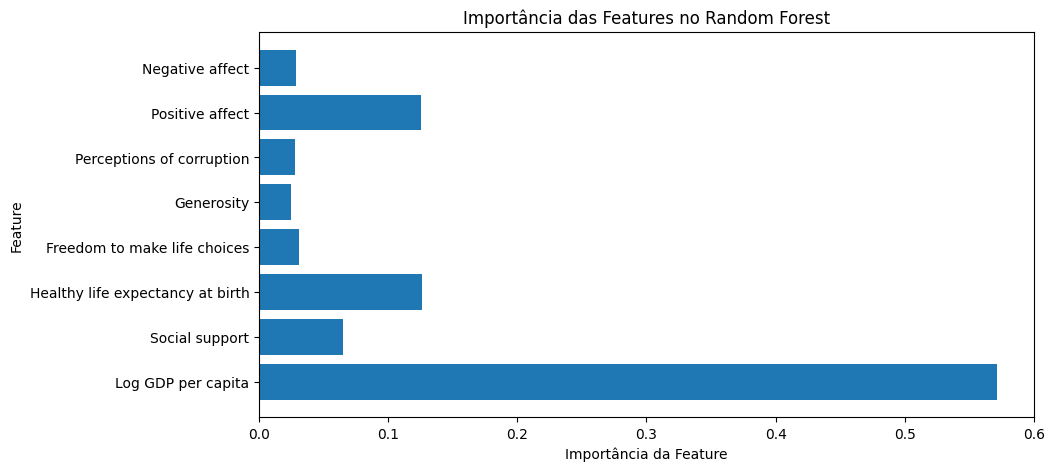

In [ ]:
# Obtendo a importância das features
importances = rf_regressor.feature_importances_

# Obtendo os nomes das features
feature_names = X.columns

# Criando um gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances)
plt.xlabel("Importância da Feature")
plt.ylabel("Feature")
plt.title("Importância das Features no Random Forest")
plt.show()

In [ ]:
#Criando objeto explainer dp SHAP para o modelo Random Forest
explainer = shap.TreeExplainer(rf_regressor, data = None, model_output='raw', feature_perturbation='tree_path_dependent')
# Calculando os valores SHAP para os dados de teste
shap_values = explainer.shap_values(X_test)

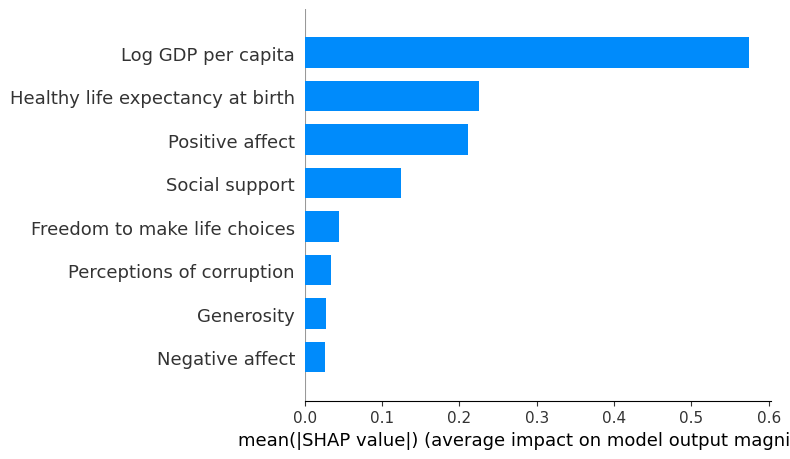

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

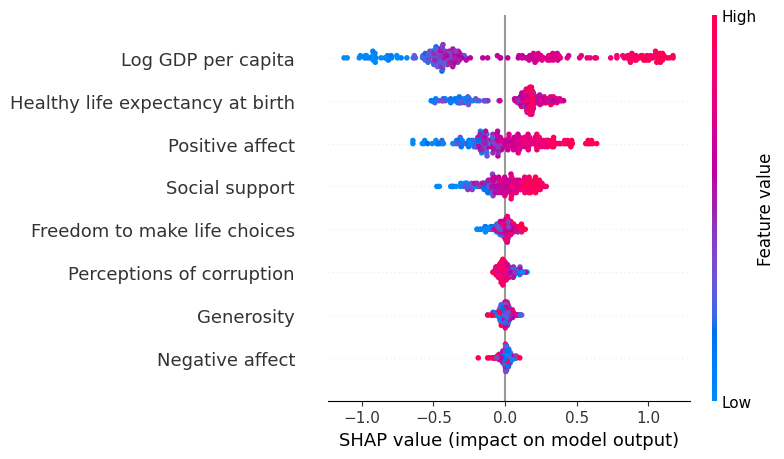

In [ ]:
shap.summary_plot(shap_values,X_test)


### Usando KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# Definindo o modelo KNN Regressor
knn_regressor = KNeighborsRegressor(n_neighbors=4)  # Definindo o número de vizinhos (k=5)

# Configurando o K-Fold
k = 10  # Número de folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Avaliação do modelo com K-Fold Cross Validation
r2_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='r2')  # R² como métrica
mae_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='neg_mean_absolute_error')  # MAE (negativo)
rmse_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='neg_root_mean_squared_error')  # RMSE (negativo)

# Previsões para todos os dados usando K-Fold
y_pred = cross_val_predict(knn_regressor, X, y, cv=kf)

# Exibindo os resultados das métricas de avaliação
print(f"Média do R²: {r2_scores.mean():.5f}")
print(f"Média do MAE: {-mae_scores.mean():.5f}")  # MAE é negativo por padrão
print(f"Média do RMSE: {-rmse_scores.mean():.5f}")  # RMSE é negativo por padrão

Média do R²: 0.85937
Média do MAE: 0.30790
Média do RMSE: 0.41785


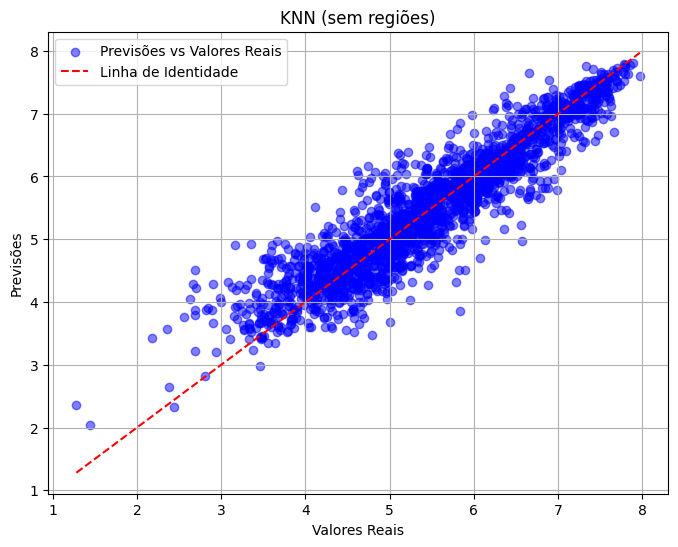

In [ ]:
# Criando o gráfico de dispersão
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5, label='Previsões vs Valores Reais')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Linha de Identidade')
plt.xlabel('Valores Reais')
plt.ylabel('Previsões')
plt.title('KNN (sem regiões)')
plt.legend()
plt.grid(True)
plt.show()

## Incluindo 'Regional indicator' no treinamento dos modelos

Vamos repetir os quatro algoritmos de AM incluindo a região no treinamento dos modelos por meio do dataframe df_regioes

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd


# Separacao de 'Regional indicator' em varios atributos binarios
encoder = OneHotEncoder(sparse_output=False, drop='first')
regioes_encoded = encoder.fit_transform(df_regioes[['Regional indicator']])

# Criando um DataFrame com os novos valores
regioes_encoded_df = pd.DataFrame(regioes_encoded, columns=encoder.get_feature_names_out(['Regional indicator']))
regioes_encoded_df.index = df_regioes.index  # Alinha o índice com o DataFrame original
df_regioes = pd.concat([df_regioes, regioes_encoded_df], axis=1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Aplicando normalização dos dados numéricos
cols_para_normalizar = ['Log GDP per capita', 'Social support', 'Healthy life expectancy at birth',
                       'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'
                       , 'Positive affect', 'Negative affect']

scaler = MinMaxScaler()

df_regioes[cols_para_normalizar] = scaler.fit_transform(df_regioes[cols_para_normalizar])

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df_regioes.drop(['Country name', 'year', 'Life Ladder', 'Regional indicator'], axis=1)
y = df_regioes['Life Ladder']


# OBS: A separação treino-teste no treinamento dos modelos será feita utilizando K-Fold

### Regressão Linear

In [ ]:
#### USANDO REGRESSÃO LINEAR COM  K-FOLD
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# Configurando o modelo
lr_regressor = LinearRegression()

# Configurando K-Fold
k = 10  # Número de folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# R²
r2_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring='r2')

# MAE
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
mae_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring=mae_scorer)

# RMSE (Usando a função atualizada)
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)
rmse_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring=rmse_scorer)

# Exibindo os resultados
print(f'Média do R²: {r2_scores.mean():.5f}')

print(f'Média do MAE: {-mae_scores.mean():.5f}')

print(f'Média do RMSE: {-rmse_scores.mean():.5f}')

Média do R²: 0.78642
Média do MAE: 0.39107
Média do RMSE: 0.51673


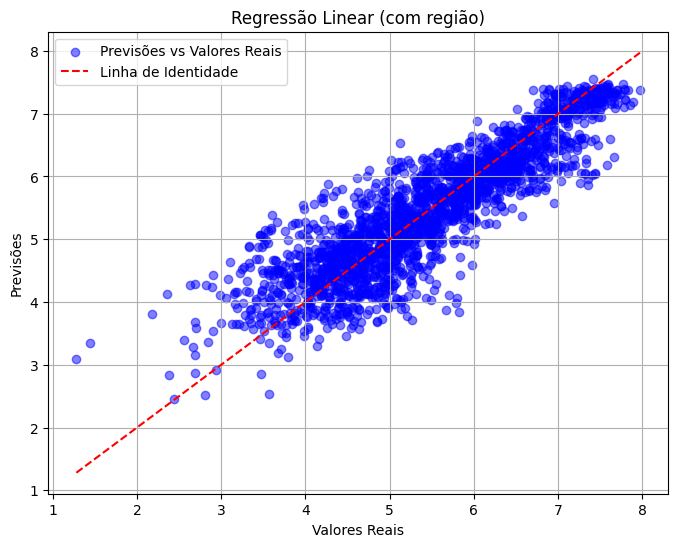

In [ ]:
from sklearn.model_selection import cross_val_predict


# Previsões no conjunto de teste usando validação cruzada
y_pred = cross_val_predict(lr_regressor, X, y, cv=kf)

# Criando o gráfico de dispersão
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5, label='Previsões vs Valores Reais')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Linha de Identidade')
plt.xlabel('Valores Reais')
plt.ylabel('Previsões')
plt.title('Regressão Linear (com região)')
plt.legend()
plt.grid(True)
plt.show()

### Random Forest

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Configurando o modelo RandomForest
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Definindo o número de folds
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Listas para armazenar os resultados
r2_scores = []
mae_scores = []
rmse_scores = []

# Lista para armazenar as previsões de todos os folds
y_pred_all = np.zeros_like(y)  # Inicializando um array de zeros com o mesmo tamanho de y

# Realizando o K-Fold
for train_index, test_index in kf.split(X):  # X é o seu conjunto de dados de entrada
    # Dividindo os dados
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Treinando o modelo
    rf_regressor.fit(X_train, y_train)

    # Fazendo previsões
    y_pred = rf_regressor.predict(X_test)

    # Armazenando as previsões no array final
    y_pred_all[test_index] = y_pred  # Coloca as previsões no lugar correto

    # Calculando as métricas para cada fold
    r2_scores.append(r2_score(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

# Exibindo os resultados
print("Média do R²:", np.mean(r2_scores))
print("Média do MAE:", np.mean(mae_scores))
print("Média do RMSE:", np.mean(rmse_scores))



Média do R²: 0.8851925817058588
Média do MAE: 0.2831052215079365
Média do RMSE: 0.3777013722522213


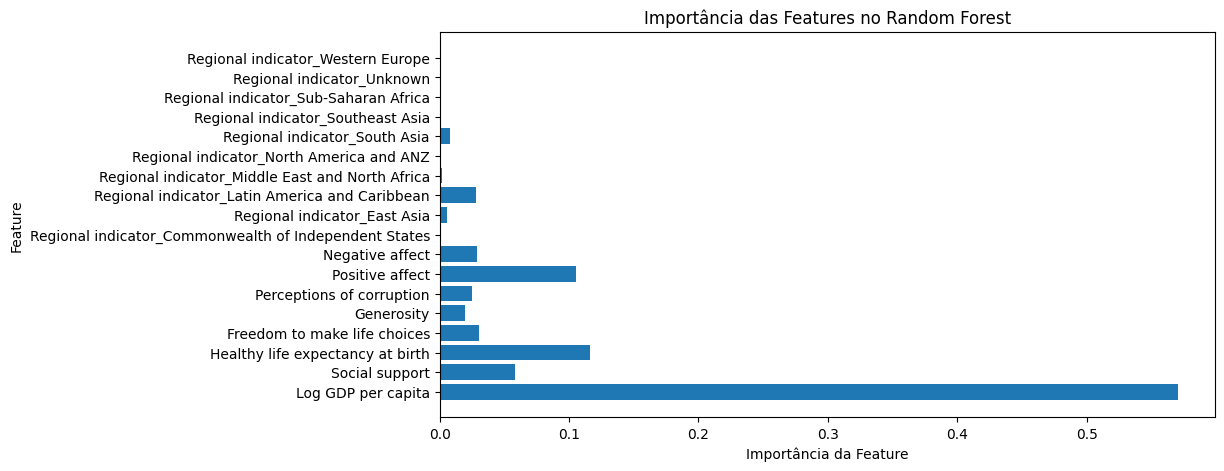

In [ ]:
# Obtendo a importância das features
importances = rf_regressor.feature_importances_

# Obtendo os nomes das features
feature_names = X.columns

# Criando um gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances)
plt.xlabel("Importância da Feature")
plt.ylabel("Feature")
plt.title("Importância das Features no Random Forest")
plt.show()

In [ ]:
features = feature_names

for i in range(len(features)):
  print(features[i], ':', importances[i])


Log GDP per capita : 0.5704682132387924
Social support : 0.057869852163431074
Healthy life expectancy at birth : 0.11619805341751639
Freedom to make life choices : 0.030046226808618324
Generosity : 0.019358652520976415
Perceptions of corruption : 0.024763399200527822
Positive affect : 0.10517145511544512
Negative affect : 0.029067360029730118
Regional indicator_Commonwealth of Independent States : 0.0005802636106534958
Regional indicator_East Asia : 0.00535816024151898
Regional indicator_Latin America and Caribbean : 0.028118863053809035
Regional indicator_Middle East and North Africa : 0.0019325221626966076
Regional indicator_North America and ANZ : 0.0003118131323834417
Regional indicator_South Asia : 0.007616843619746123
Regional indicator_Southeast Asia : 0.001119228316697932
Regional indicator_Sub-Saharan Africa : 0.00046367482622402796
Regional indicator_Unknown : 0.0010105660983793542
Regional indicator_Western Europe : 0.0005448524428535612


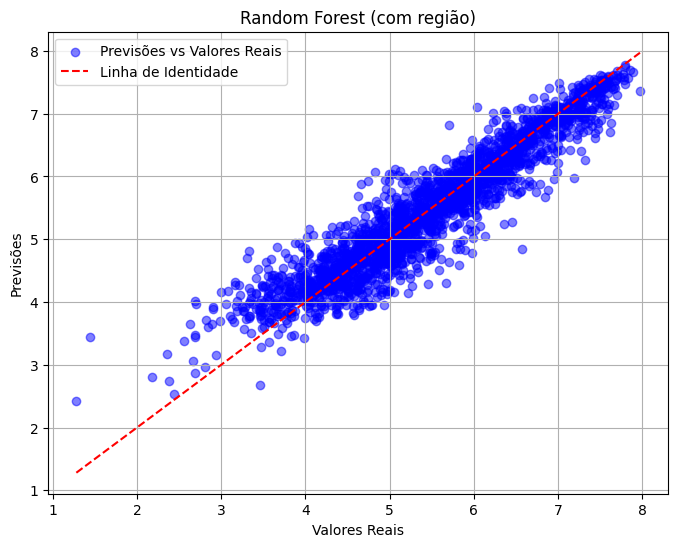

In [ ]:
# Criando o gráfico de dispersão
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_all, color='blue', alpha=0.5, label='Previsões vs Valores Reais')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Linha de Identidade')
plt.xlabel('Valores Reais')
plt.ylabel('Previsões')
plt.title('Random Forest (com região)')
plt.legend()
plt.grid(True)
plt.show()

### Árvore de Decisão

In [ ]:
from sklearn.tree import DecisionTreeRegressor


# Configurando o modelo
dt_regressor = DecisionTreeRegressor(random_state=42)  # Ajuste max_depth conforme necessário

# Configurando o K-Fold
k = 10  # Número de folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)



# Avaliando com K-Fold
r2_scores = cross_val_score(dt_regressor, X, y, cv=kf, scoring='r2')
mae_scores = cross_val_score(dt_regressor, X, y, cv=kf, scoring=make_scorer(mean_absolute_error, greater_is_better=False))
rmse_scores = cross_val_score(dt_regressor, X, y, cv=kf, scoring=make_scorer(root_mean_squared_error, greater_is_better=False))

# Fazendo previsões para todo o dataset e salvando
y_pred = cross_val_predict(dt_regressor, X, y, cv=kf)

# Exibindo resultados
print(f"Média do R²: {r2_scores.mean():.5f}")
print(f"Média do MAE: {-mae_scores.mean():.5f}")  # MAE deve ser positivo
print(f"Média do RMSE: {-rmse_scores.mean():.5f}")  # RMSE deve ser positivo

Média do R²: 0.77229
Média do MAE: 0.39013
Média do RMSE: 0.53263


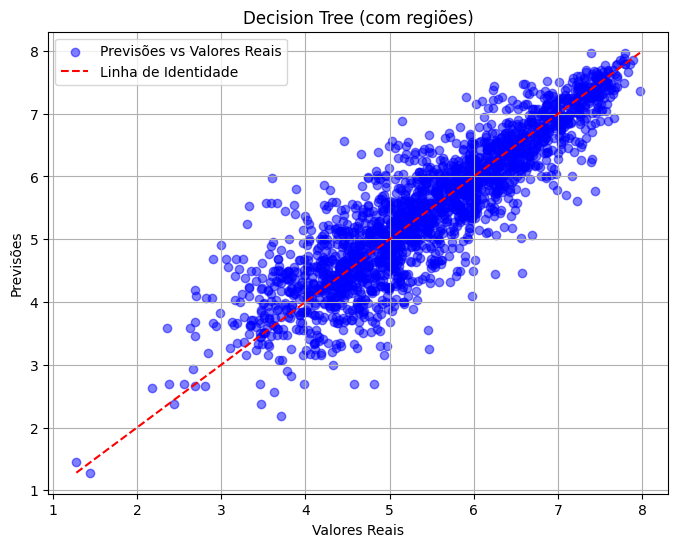

In [ ]:
# Criando o gráfico de dispersão
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5, label='Previsões vs Valores Reais')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Linha de Identidade')
plt.xlabel('Valores Reais')
plt.ylabel('Previsões')
plt.title('Decision Tree (com regiões)')
plt.legend()
plt.grid(True)
plt.show()

### KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# Definindo o modelo KNN Regressor
knn_regressor = KNeighborsRegressor(n_neighbors=4)  # Definindo o número de vizinhos (k=5)

# Configurando o K-Fold
k = 10  # Número de folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Avaliação do modelo com K-Fold Cross Validation
r2_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='r2')  # R² como métrica
mae_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='neg_mean_absolute_error')  # MAE (negativo)
rmse_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='neg_root_mean_squared_error')  # RMSE (negativo)

# Previsões para todos os dados usando K-Fold
y_pred = cross_val_predict(knn_regressor, X, y, cv=kf)

# Exibindo os resultados das métricas de avaliação
print(f"Média do R²: {r2_scores.mean():.5f}")
print(f"Média do MAE: {-mae_scores.mean():.5f}")  # MAE é negativo por padrão
print(f"Média do RMSE: {-rmse_scores.mean():.5f}")  # RMSE é negativo por padrão

Média do R²: 0.87997
Média do MAE: 0.28414
Média do RMSE: 0.38610


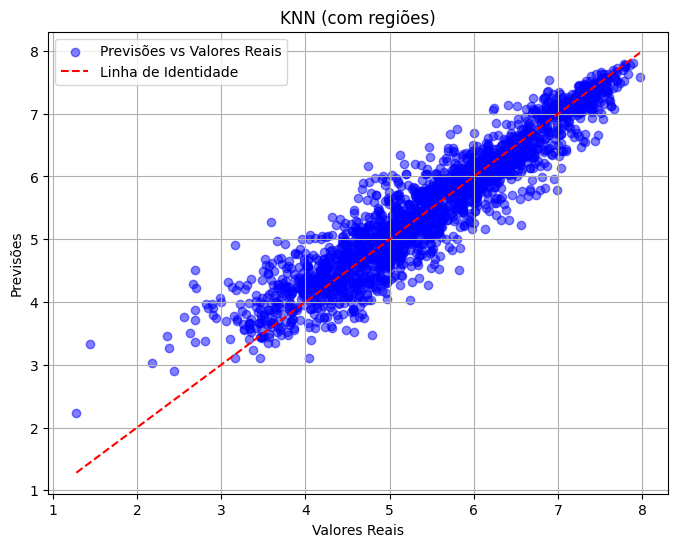

In [ ]:
# Criando o gráfico de dispersão
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5, label='Previsões vs Valores Reais')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Linha de Identidade')
plt.xlabel('Valores Reais')
plt.ylabel('Previsões')
plt.title('KNN (com regiões)')
plt.legend()
plt.grid(True)
plt.show()